# Bitcoin Whale Intelligence - Erklärt


Dieses Notebook erklärt Schritt für Schritt, wie wir Bitcoin-"Wale" (große Besitzer) identifizieren und deren Vermögensentwicklung über Zeit analysieren.

**Das Problem:** Auf der Blockchain sind nur Adressen sichtbar, nicht Personen. Ein Besitzer kann hunderte Adressen haben.

**Die Lösung:** 
1. **Clustering:** Adressen, die derselben Person gehören, werden gruppiert
2. **Zeitreihen:** Die Balance-Entwicklung jeder Entität wird über Zeit verfolgt

---

| Abschnitt | Beschreibung |
|-----------|--------------|
| 1. Das Problem | Warum Whale-Analyse? |
| 2. UTXO-Modell | Bitcoin hat keine Konten |
| 3. Setup | Konfiguration, Parallelisierung |
| 3.1 Schemas & Helper | Datenstrukturen, Fail-Safe |
| 4. Daten laden | JSON zu Spark DataFrames |
| 5. Outputs extrahieren | Nested zu Flach |
| 6. Inputs extrahieren | Nested zu Flach |
| 7. UTXO berechnen | Unspent Outputs finden |
| 8. Common Input Heuristic | Adressen gruppieren |
| 8.1 CoinJoin-Filterung | Privacy-TXs ausfiltern |
| 9. Graph bauen | Adressen als Netzwerk |
| 10. Connected Components | Entities finden |
| 11. Whale Detection | Große Besitzer finden |
| 12. Visualisierung | Whale-Verteilung |
| 13. Zeitreihen-Analyse | Balance über Zeit |
| 14. Executive Summary | Ergebnisse & Erkenntnisse |
| 15. Zusammenfassung | Die komplette Pipeline |

---
## Setup-Anleitung

> **Voraussetzungen:**
- Java 11 oder Java 17 (für Spark 4.x)
- Python 3.11+

### Schritt 1: Python virtuelle Umgebung einrichten
```bash
python -m venv .venv
```

Umgebung auf Windows aktivieren:
```bash
venv\Scripts\Activate.ps1
```

Umgebung auf macOS/Linux aktivieren:
```bash
source venv/bin/activate
```

### Schritt 2: PySpark und zusätzliche Pakete installieren

```bash
pip install ipykernel>=7.1.0 pyspark>=4.1.1 graphframes-py>=0.10.1 matplotlib>=3.10.8 psutil>=7.2.1 pyarrow>=23.0.0 seaborn>=0.13.2
```

---

### Schritt 3: Dataset herunterladen

Wähle ein Dataset je nach verfügbarem Speicherplatz:

| Dataset | Komprimiert | Entpackt | Link |
|---------|-------------|----------|------|
| **Klein** | ~200 MB | ~1 GB | [Download](https://drive.google.com/file/d/1cjEeRarQR2jGw10CzSCkbczFDldn_jBR/view?usp=sharing) |
| **Groß** | ~4 GB | ~20 GB | [Download](https://drive.google.com/file/d/1NTtyUTrDkFNAY1IJ3lhYB-7eiz09REYk/view?usp=sharing) |

**Schritte:**
1. ZIP-Datei herunterladen
2. Entpacken in den `blockchain_exports` Ordner
3. Pfad zum Ordner merken

Erwartete Struktur:
```
blockchain_exports/              ← Diesen Pfad im Notebook angeben
└── 2024-01-15_2024-02-04/      ← Entpacktes Dataset (Ordnername = Datumsbereich)
    ├── blocks/*.json
    └── transactions/*.json
```

**Hinweis:** Der Ordnername des Datasets (z.B. `2024-01-15_2024-02-04`) entspricht dem Zeitraum der Blockchain-Daten. Es können auch mehrere Datasets im `blockchain_exports` Ordner liegen.

---

### Schritt 4: Pfade anpassen

In **Abschnitt 3 → erste Code-Zelle** diese zwei Variablen anpassen:

| Variable | Beispiel macOS | Beispiel Windows |
|----------|----------------|------------------|
| `BLOCKCHAIN_DATA_PATH` | `"/Users/Name/blockchain_exports"` | `r"C:\Users\Name\blockchain_exports"` |
| `OUTPUT_PATH` | `"/Users/Name/output"` | `r"C:\Users\Name\output"` |

---

### Schritt 5: Notebook ausführen

Alle Zellen der Reihe nach ausführen: **Shift + Enter** oder Menü → Run All

---

---
## Methodische Grundlagen

Diese Analyse basiert auf etablierten Methoden der Bitcoin-Blockchain-Forschung:

### UTXO-Modell (Unspent Transaction Output)
Das fundamentale Transaktionsmodell von Bitcoin. Jede Transaktion verbraucht vorherige Outputs als Inputs und erzeugt neue Outputs.
- [Bitcoin Developer Documentation](https://developer.bitcoin.org/devguide/transactions.html)
- [Learn Me A Bitcoin - UTXO](https://learnmeabitcoin.com/technical/transaction/utxo/)

### Common-Input-Ownership Heuristik
Die Annahme, dass alle Inputs einer Transaktion derselben Entität gehören, da der Sender alle zugehörigen privaten Schlüssel besitzen muss.
- [Bitcoin Wiki - Common-input-ownership heuristic](https://en.bitcoin.it/wiki/Common-input-ownership_heuristic)
- [River Financial Glossary](https://river.com/learn/terms/c/common-input-ownership-heuristic/)

### Address Clustering
Die Gruppierung von Bitcoin-Adressen zu Entitäten mittels Heuristiken, etabliert durch akademische Forschung.
- [Meiklejohn et al., "A Fistful of Bitcoins"](https://cseweb.ucsd.edu/~smeiklejohn/files/imc13.pdf)
- [Chainalysis - Blockchain Intelligence](https://www.chainalysis.com/blockchain-intelligence/)
- [He et al., IET Blockchain](https://ietresearch.onlinelibrary.wiley.com/doi/full/10.1049/blc2.12014)

### CoinJoin-Erkennung
Die Filterung von Privacy-Transaktionen (CoinJoin), um False Positives beim Clustering zu vermeiden.
- [Schnoering & Vazirgiannis, "Heuristics for Detecting CoinJoin Transactions on the Bitcoin Blockchain"](https://arxiv.org/abs/2311.12491) - Akademische Heuristiken für Whirlpool, Wasabi und JoinMarket
- [Samourai Wallet - Whirlpool Documentation](https://docs.samourai.io/whirlpool/basic-concepts) - Offizielle Pool-Denominationen (0.001, 0.01, 0.05, 0.5 BTC)
- [MIT DCI - Evaluating Whirlpool](https://www.dci.mit.edu/posts/coinjoin-timing-questions) - Unabhängige Analyse des Whirlpool-Protokolls

### Whale-Klassifikation
Die Kategorisierung von Bitcoin-Besitzern nach Größe (Entity-basiert, nicht Adress-basiert).
- [Glassnode - Ultimate Guide to Bitcoin Whales](https://insights.glassnode.com/content/the-ultimate-guide-to-bitcoin-whales-2/)
- [Glassnode - Bitcoin Supply Distribution](https://insights.glassnode.com/bitcoin-supply-distribution/)

---


---
## 1. Das Problem: Adressen sind nicht Personen

```
┌─────────────────────────────────────────────────────────────────────┐
│                    WAS WIR AUF DER BLOCKCHAIN SEHEN                 │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│   ┌───────────────┐   ┌───────────────┐   ┌───────────────┐         │
│   │  Adresse A    │   │  Adresse B    │   │  Adresse C    │         │
│   │   500 BTC     │   │   300 BTC     │   │   200 BTC     │         │
│   └───────────────┘   └───────────────┘   └───────────────┘         │
│                                                                     │
│   Sieht aus wie 3 verschiedene Besitzer mit je 200-500 BTC          │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
                              │
                              ▼ Analyse
┌─────────────────────────────────────────────────────────────────────┐
│                    DIE REALITÄT (versteckt)                         │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│           ┌───────────────────────────────────────┐                 │
│           │         EINE PERSON / ENTITY          │                 │
│           │              1.000 BTC                │                 │
│           │   (kontrolliert A, B und C)           │                 │
│           └───────────────────────────────────────┘                 │
│                                                                     │
│   Das ist ein WAL! Aber ohne Analyse bliebe dies verborgen.         │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
```

**Warum ist das wichtig?**
- Börsen haben tausende Adressen
- Privacy-bewusste Nutzer verwenden neue Adressen pro Transaktion
- Echte Vermögensverteilung ist ohne Clustering unsichtbar

---
## 2. Das UTXO-Modell: Bitcoin hat keine "Konten"

Das UTXO-Modell (Unspent Transaction Output) ist fundamental für das Verständnis von Bitcoin. Im Gegensatz zu traditionellen Bankensystemen speichert Bitcoin keine Kontostände, sondern verwaltet eine Menge von "unverbrauchten Outputs".

```
┌─────────────────────────────────────────────────────────────────────┐
│                      BANK-MODELL (Nicht Bitcoin!)                   │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│   Konto 123:  Kontostand = 1.000 EUR                                │
│               ─────────────────────                                 │
│               Eine Zahl, die aktualisiert wird                      │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────┐
│                      BITCOIN: UTXO-MODELL                           │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│   Adresse A besitzt diese "Münzen" (UTXOs):                         │
│                                                                     │
│   ┌─────────┐  ┌─────────┐  ┌─────────┐                             │
│   │ 0.5 BTC │  │ 0.3 BTC │  │ 0.2 BTC │  = 1.0 BTC Guthaben         │
│   └─────────┘  └─────────┘  └─────────┘                             │
│                                                                     │
│   Wie Bargeld-Scheine: Jeder UTXO ist eine separate "Münze"         │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
```

**Eine Bitcoin-Transaktion funktioniert so:**

```
┌─────────────────┐                         ┌─────────────────┐
│    INPUTS       │                         │    OUTPUTS      │
│  (ausgeben)     │                         │  (neue UTXOs)   │
├─────────────────┤     ┌───────────┐       ├─────────────────┤
│  ┌───────────┐  │     │           │       │  ┌───────────┐  │
│  │  0.5 BTC  │──┼────▶│           │──────▶│  │  0.7 BTC  │  │  Empfänger
│  └───────────┘  │     │    TX     │       │  └───────────┘  │
│  ┌───────────┐  │     │           │       │  ┌───────────┐  │
│  │  0.3 BTC  │──┼────▶│           │──────▶│  │ 0.09 BTC  │  │  Wechselgeld
│  └───────────┘  │     └───────────┘       │  └───────────┘  │
└─────────────────┘      Gebühr: 0.01       └─────────────────┘
    0.8 BTC rein             BTC               0.79 BTC raus
```

**Wichtig:** Um einen UTXO auszugeben, braucht man den Private Key der Adresse!

---
## 3. Setup und Konfiguration

```
┌─────────────────────────────────────────────────────────────────────┐
│                        DATENQUELLE                                  │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│  ┌──────────────┐      ┌──────────────┐      ┌──────────────┐       │
│  │   Bitcoin    │      │  bitcoin-etl │      │    JSON      │       │
│  │  Full Node   │─────▶│   (Export)   │─────▶│   Dateien    │       │
│  └──────────────┘      └──────────────┘      └──────────────┘       │
│                                                                     │
│  Die Blockchain        Konvertiert zu        Unser Input            │
│  (raw 900+ GB)         lesbarem Format       (Blocks + TXs)         │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
```

**Warum Spark?** Die Blockchain ist zu groß für Pandas. Spark verteilt die Arbeit auf alle CPU-Kerne.

```
┌─────────────────────────────────────────────────────────────────────┐
│                    PARALLELISIERUNGS-STRATEGIE                      │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│   ┌─────────────────────────────────────────────────────────────┐   │
│   │                    Spark Cluster (local[*])                 │   │
│   │  ┌─────┐  ┌─────┐  ┌─────┐  ┌─────┐  ┌─────┐  ┌─────┐       │   │
│   │  │Core1│  │Core2│  │Core3│  │Core4│  │ ... │  │CoreN│       │   │
│   │  └──┬──┘  └──┬──┘  └──┬──┘  └──┬──┘  └──┬──┘  └──┬──┘       │   │
│   │     └────────┴────────┴────────┴────────┴────────┘          │   │
│   │                         │                                   │   │
│   │              ┌──────────▼──────────┐                        │   │
│   │              │ Adaptive Query Exec │                        │   │
│   │              │  - Partition Tuning │                        │   │
│   │              │  - Skew Handling    │                        │   │
│   │              └─────────────────────┘                        │   │
│   └─────────────────────────────────────────────────────────────┘   │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
```

**Parallelisierungs-Konfiguration:**

| Parameter | Wert | Erklärung |
|-----------|------|-----------|
| `local[*]` | Alle Cores | Nutzt alle verfügbaren CPU-Kerne |
| `shuffle.partitions` | Dynamisch | Berechnet aus RAM/Cores via `get_optimal_partitions()` |
| `adaptive.enabled` | true | Spark optimiert Query-Pläne zur Laufzeit |
| `skewJoin.enabled` | true | Verhindert Hotspots bei ungleich verteilten Daten |
| `autoBroadcastJoinThreshold` | 10MB | Kleine Tabellen werden an alle Executors verteilt |

In [10]:
# ==============================================================================
# IMPORTS
# ==============================================================================
import os
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col,
    collect_list,
    collect_set,
    count,
    desc,
    element_at,
    explode,
    explode_outer,
    from_unixtime,
    lit,
    to_timestamp,
    udf,
    when,
)
from pyspark.sql.functions import (
    max as spark_max,
)
from pyspark.sql.functions import (
    round as spark_round,
)
from pyspark.sql.functions import (
    size as spark_size,
)
from pyspark.sql.functions import (
    sum as spark_sum,
)
from pyspark.sql.types import ArrayType, BooleanType, IntegerType, LongType, StringType, StructField, StructType

# Visualization style
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.figsize": (12, 6),
        "figure.dpi": 100,
        "axes.titlesize": 14,
        "axes.titleweight": "bold",
        "axes.labelsize": 11,
        "font.size": 10,
    }
)
COLORS = {"primary": "#2E86AB", "secondary": "#A23B72", "accent": "#F18F01", "dark": "#1B1B1E"}

In [11]:
# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║                    HIER ANPASSEN (siehe Anleitung oben)                   ║
# ╚═══════════════════════════════════════════════════════════════════════════╝

BLOCKCHAIN_DATA_PATH = "../blockchain_exports"  # ← Ordner mit Dataset(s)
OUTPUT_PATH = "../output"  # ← Ordner für Ergebnisse
# BLOCKCHAIN_DATA_PATH = "/HIER/PFAD/ZUM/blockchain_exports"   # ← Ordner mit Dataset(s)
# OUTPUT_PATH = "/HIER/PFAD/FUER/output"                       # ← Ordner für Ergebnisse

# Romans lokale Pfade
# BLOCKCHAIN_DATA_PATH = "/Users/roman/spark_project/blockchain_exports"
# OUTPUT_PATH = "/Users/roman/spark_project/output-notebook"

# ═══════════════════════════════════════════════════════════════════════════════
# Ab hier nichts ändern
# ═══════════════════════════════════════════════════════════════════════════════
DRIVER_MEMORY = "8g"
LARGE_DATASET_MODE = True

Path(OUTPUT_PATH).mkdir(parents=True, exist_ok=True)

# Prüfung
if "HIER/PFAD" in BLOCKCHAIN_DATA_PATH:
    msg = "Bitte BLOCKCHAIN_DATA_PATH anpassen! Siehe Anleitung oben."
    raise ValueError(msg)
if not Path(BLOCKCHAIN_DATA_PATH).exists():
    msg = f"Ordner nicht gefunden: {BLOCKCHAIN_DATA_PATH}"
    raise FileNotFoundError(msg)

print(f"✓ Dataset-Ordner: {BLOCKCHAIN_DATA_PATH}")
print(f"✓ Output-Ordner:  {OUTPUT_PATH}")

✓ Dataset-Ordner: ../blockchain_exports
✓ Output-Ordner:  ../output


---
## 3.1 Schemas und Helper-Funktionen

```
┌─────────────────────────────────────────────────────────────────────┐
│                    JSON STRUKTUR (bitcoin-etl)                      │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│  Transaction JSON:                                                  │
│  {                                                                  │
│    "hash": "abc123...",                                             │
│    "block_number": 100000,                                          │
│    "inputs": [                      <-- Array von Inputs            │
│      { "spent_transaction_hash": "xyz", "value": 50000000 }         │
│    ],                                                               │
│    "outputs": [                     <-- Array von Outputs           │
│      { "index": 0, "value": 40000000, "addresses": ["1A..."] }      │
│    ]                                                                │
│  }                                                                  │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
```

**Schemas:** Durch vordefinierte StructTypes wird das JSON-Parsing beschleunigt - Spark muss die Struktur nicht selbst inferieren.

```
┌─────────────────────────────────────────────────────────────────────┐
│                    FAIL-SAFE MECHANISMEN                            │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│   ┌─────────────┐     ┌─────────────┐     ┌─────────────┐           │
│   │   Logging   │────▶│   Retry     │────▶│  Checkpoint │           │
│   │  (Tracking) │     │ (Recovery)  │     │ (Persistenz)│           │
│   └─────────────┘     └─────────────┘     └─────────────┘           │
│                                                                     │
│   1. Logging: Alle Operationen werden protokolliert                 │
│   2. Retry: Automatische Wiederholung bei transienten Fehlern       │
│   3. Checkpointing: Zwischenergebnisse als Parquet materialisiert   │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
```

**Implementierte Fail-Safe Mechanismen:**

| Mechanismus | Funktion | Zweck |
|-------------|----------|-------|
| `retry_on_failure()` | Decorator | Exponential Backoff bei I/O-Fehlern |
| `safe_write_parquet()` | Helper | Schreiben mit Fehlerbehandlung |
| `logging` | Framework | Strukturierte Protokollierung statt print() |

In [12]:
# ==============================================================================
# SCHEMAS FÜR BITCOIN-ETL JSON DATEN
# ==============================================================================

INPUT_SCHEMA = StructType(
    [
        StructField("index", IntegerType(), True),
        StructField("spent_transaction_hash", StringType(), True),
        StructField("spent_output_index", IntegerType(), True),
        StructField("script_asm", StringType(), True),
        StructField("script_hex", StringType(), True),
        StructField("sequence", LongType(), True),
        StructField("required_signatures", IntegerType(), True),
        StructField("type", StringType(), True),
        StructField("addresses", ArrayType(StringType()), True),
        StructField("value", LongType(), True),
    ]
)

OUTPUT_SCHEMA = StructType(
    [
        StructField("index", IntegerType(), True),
        StructField("script_asm", StringType(), True),
        StructField("script_hex", StringType(), True),
        StructField("required_signatures", IntegerType(), True),
        StructField("type", StringType(), True),
        StructField("addresses", ArrayType(StringType()), True),
        StructField("value", LongType(), True),
    ]
)

TRANSACTION_SCHEMA = StructType(
    [
        StructField("hash", StringType(), False),
        StructField("size", IntegerType(), True),
        StructField("virtual_size", IntegerType(), True),
        StructField("version", IntegerType(), True),
        StructField("lock_time", LongType(), True),
        StructField("block_number", LongType(), True),
        StructField("block_hash", StringType(), True),
        StructField("block_timestamp", LongType(), True),
        StructField("is_coinbase", BooleanType(), True),
        StructField("index", IntegerType(), True),
        StructField("inputs", ArrayType(INPUT_SCHEMA), True),
        StructField("outputs", ArrayType(OUTPUT_SCHEMA), True),
        StructField("input_count", IntegerType(), True),
        StructField("output_count", IntegerType(), True),
        StructField("input_value", LongType(), True),
        StructField("output_value", LongType(), True),
        StructField("fee", LongType(), True),
    ]
)

BLOCK_SCHEMA = StructType(
    [
        StructField("hash", StringType(), False),
        StructField("size", IntegerType(), True),
        StructField("stripped_size", IntegerType(), True),
        StructField("weight", IntegerType(), True),
        StructField("number", LongType(), True),
        StructField("version", IntegerType(), True),
        StructField("merkle_root", StringType(), True),
        StructField("timestamp", LongType(), True),
        StructField("nonce", StringType(), True),
        StructField("bits", StringType(), True),
        StructField("coinbase_param", StringType(), True),
        StructField("transaction_count", IntegerType(), True),
    ]
)

print("Schemas definiert.")

Schemas definiert.


In [13]:
# ==============================================================================
# HELPER FUNKTIONEN
# ==============================================================================

import logging
import time
from collections.abc import Callable
from functools import wraps
from pathlib import Path
from typing import ParamSpec, TypeVar

import psutil
from pyspark.sql import DataFrame

# ------------------------------------------------------------------------------
# LOGGING FRAMEWORK
# Ersetzt print() durch strukturiertes Logging für bessere Nachvollziehbarkeit
# ------------------------------------------------------------------------------
logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")
logger = logging.getLogger(__name__)


# ------------------------------------------------------------------------------
# FAIL-SAFE: RETRY DECORATOR
# Automatische Wiederholung bei transienten Fehlern mit Exponential Backoff
# ------------------------------------------------------------------------------

P = ParamSpec("P")
T = TypeVar("T")


def retry_on_failure(max_attempts: int = 3, delay: int = 1) -> Callable[[Callable[P, T]], Callable[P, T]]:
    """Wiederholt Funktionsaufrufe automatisch bei Fehlern.

    Implementiert exponentielles Backoff: Wartezeit verdoppelt sich mit jedem Versuch.
    Typische Anwendung: I/O-Operationen, Netzwerkzugriffe, Spark-Jobs.

    Args:
        max_attempts: Maximale Anzahl der Versuche (default: 3)
        delay: Initiale Wartezeit in Sekunden (default: 1)

    Returns:
        Decorator-Funktion

    """

    def decorator(func: Callable[P, T]) -> Callable[P, T]:
        @wraps(func)
        def wrapper(*args: P.args, **kwargs: P.kwargs) -> T:
            last_exception: Exception | None = None
            for attempt in range(max_attempts):
                try:
                    return func(*args, **kwargs)
                except Exception as e:
                    last_exception = e
                    if attempt < max_attempts - 1:
                        wait_time = delay * (2**attempt)  # Exponential backoff
                        logger.warning("Versuch %d/%d fehlgeschlagen: %s", attempt + 1, max_attempts, e)
                        logger.info("Warte %ds vor nächstem Versuch...", wait_time)
                        time.sleep(wait_time)
                    else:
                        logger.error("Alle %d Versuche fehlgeschlagen für %s", max_attempts, func.__name__)

            # If we get here, all attempts failed
            if last_exception is not None:
                raise last_exception
            # This should never happen, but satisfies type checker
            msg = f"Unexpected error in retry_on_failure for {func.__name__}"
            raise RuntimeError(msg)

        return wrapper

    return decorator


# ------------------------------------------------------------------------------
# FAIL-SAFE: SAFE WRITE FUNKTION
# Sicheres Schreiben mit Fehlerbehandlung und Logging
# ------------------------------------------------------------------------------
def safe_write_parquet(df: DataFrame, path: str, name: str = "DataFrame") -> bool:
    """Schreibt DataFrame mit Fehlerbehandlung und Logging.

    Features:
    - Ausführliches Logging vor/nach Schreibvorgang
    - Validierung dass Datei erstellt wurde
    - Exception Handling mit informativen Fehlermeldungen

    Args:
        df: Spark DataFrame zum Speichern
        path: Zielpfad für Parquet-Datei
        name: Beschreibender Name für Logging

    Returns:
        bool: True bei Erfolg

    """
    try:
        logger.info("Schreibe %s nach %s...", name, path)
        df.write.mode("overwrite").parquet(path)

        if Path(path).exists():
            logger.info("[OK] %s erfolgreich gespeichert: %s", name, path)
            return True
        msg = f"Datei wurde nicht erstellt: {path}"
        raise OSError(msg)

    except Exception as e:
        logger.error("[FEHLER] Fehler beim Speichern von %s: %s", name, e)
        raise


# ------------------------------------------------------------------------------
# PARALLELISIERUNG: DYNAMISCHE PARTITION-BERECHNUNG
# Optimiert Partitions basierend auf verfügbaren System-Ressourcen
# ------------------------------------------------------------------------------
def get_optimal_partitions() -> int:
    """Berechnet optimale Partition-Anzahl basierend auf System-Ressourcen.

    Strategie:
    - Basis: 2-4 Partitions pro CPU-Core für gute Parallelisierung
    - Skalierung mit RAM: Mehr Speicher erlaubt mehr parallele Tasks
    - Minimum 200 Partitions für ausreichende Granularität
    - Maximum begrenzt um Scheduling-Overhead zu vermeiden

    Returns:
        int: Optimale Anzahl der Shuffle-Partitions

    """
    cores = os.cpu_count() or 4
    memory_gb = psutil.virtual_memory().total / (1024**3)
    # Faustregel: 2-4 Partitions pro Core, skaliert mit RAM
    return max(200, min(cores * 4, int(memory_gb * 10)))


# ------------------------------------------------------------------------------
# SPARK SESSION MIT OPTIMIERTER PARALLELISIERUNG
# ------------------------------------------------------------------------------
def create_spark_session(
    app_name: str = "Bitcoin Whale Intelligence",
    driver_memory: str = "8g",
    *,
    enable_graphframes: bool = True,
    suppress_logs: bool = True,
) -> SparkSession:
    """Erstellt eine optimierte Spark Session für Bitcoin-Datenverarbeitung.

    Optimiert für große Datasets (20GB+).

    Parallelisierungs-Strategie:
    - local[*]: Nutzt alle verfügbaren CPU-Kerne
    - Dynamische Partition-Berechnung statt statischer Werte
    - Adaptive Query Execution (AQE) für Laufzeit-Optimierung
    - Skew-Join Handling für ungleich verteilte Daten
    - Broadcast-Joins für kleine Lookup-Tabellen (< 10MB)

    """
    # Dynamische Partition-Berechnung basierend auf verfügbaren Ressourcen
    optimal_partitions = get_optimal_partitions()
    cores = os.cpu_count() or 4
    memory_gb = psutil.virtual_memory().total / (1024**3)
    logger.info("System: %d Cores, %.1fGB RAM -> %d Partitions", cores, memory_gb, optimal_partitions)

    # Windows fix: local[*] causes Python worker crashes on Windows + PySpark 4.x
    # Use fixed number of workers to avoid process spawning issues
    workers = min(cores, 8)  # Cap at 8 to avoid Windows process spawning overhead

    builder = (
        SparkSession.builder.appName(app_name)
        .master(f"local[{workers}]")
        .config("spark.driver.memory", driver_memory)
        .config("spark.driver.maxResultSize", "4g")
        .config("spark.sql.adaptive.enabled", "true")
        .config("spark.sql.execution.pyspark.udf.faulthandler.enabled", "true")
        .config("spark.python.worker.faulthandler.enabled", "true")
        .config("spark.sql.adaptive.coalescePartitions.enabled", "true")
        .config("spark.sql.adaptive.skewJoin.enabled", "true")
        .config("spark.sql.shuffle.partitions", str(optimal_partitions))
        .config("spark.sql.debug.maxToStringFields", "100")
        .config("spark.ui.showConsoleProgress", "false")
        .config("spark.memory.fraction", "0.8")
        .config("spark.memory.storageFraction", "0.2")
        .config("spark.sql.files.maxPartitionBytes", "64m")
        .config("spark.sql.autoBroadcastJoinThreshold", "10485760")
    )  # 10MB Broadcast-Threshold

    if enable_graphframes:
        builder = builder.config("spark.jars.packages", "io.graphframes:graphframes-spark4_2.13:0.10.1")

    if suppress_logs:
        devnull = os.open(os.devnull, os.O_WRONLY)
        old_stdout_fd = os.dup(1)
        old_stderr_fd = os.dup(2)
        os.dup2(devnull, 1)
        os.dup2(devnull, 2)
        try:
            spark = builder.getOrCreate()
            spark.sparkContext.setLogLevel("ERROR")
        finally:
            os.dup2(old_stdout_fd, 1)
            os.dup2(old_stderr_fd, 2)
            os.close(devnull)
            os.close(old_stdout_fd)
            os.close(old_stderr_fd)
    else:
        spark = builder.getOrCreate()
        spark.sparkContext.setLogLevel("ERROR")

    logger.info("Spark Session erstellt: %s Driver Memory, AQE aktiviert", driver_memory)
    return spark


# ------------------------------------------------------------------------------
# DATEN LADEN MIT RETRY-LOGIK
# ------------------------------------------------------------------------------
@retry_on_failure(max_attempts=3, delay=2)
def load_transactions(spark: SparkSession, base_path: str, use_schema: bool = True) -> DataFrame:
    """Lädt bitcoin-etl Transaktionsdaten aus Hive-partitionierten JSON-Dateien.

    Mit automatischer Wiederholung bei Fehlern (Retry-Decorator).

    """
    logger.info("Lade Transaktionen aus %s", base_path)

    base = Path(base_path)
    batch_folders = [d for d in base.iterdir() if d.is_dir() and not d.name.startswith(".")]

    if not batch_folders:
        msg = f"Keine Batch-Ordner gefunden in {base_path}"
        raise ValueError(msg)

    tx_paths = []
    for batch in batch_folders:
        tx_path = batch / "transactions"
        if tx_path.exists():
            tx_paths.append(str(tx_path))

    if not tx_paths:
        msg = "Keine transactions/ Ordner gefunden"
        raise ValueError(msg)

    logger.info("Gefunden: %d Transaction-Ordner", len(tx_paths))

    df = spark.read.schema(TRANSACTION_SCHEMA).json(tx_paths) if use_schema else spark.read.json(tx_paths)

    df = df.withColumn("block_datetime", to_timestamp(from_unixtime(col("block_timestamp"))))
    logger.info("Transaktionen erfolgreich geladen")
    return df


@retry_on_failure(max_attempts=3, delay=2)
def load_blocks(spark: SparkSession, base_path: str, use_schema: bool = True) -> DataFrame:
    """Lädt bitcoin-etl Block-Daten aus Hive-partitionierten JSON-Dateien.

    Mit automatischer Wiederholung bei Fehlern (Retry-Decorator).

    """
    logger.info("Lade Blöcke aus %s", base_path)

    base = Path(base_path)
    batch_folders = [d for d in base.iterdir() if d.is_dir() and not d.name.startswith(".")]

    block_paths = []
    for batch in batch_folders:
        block_path = batch / "blocks"
        if block_path.exists():
            block_paths.append(str(block_path))

    if not block_paths:
        msg = "Keine blocks/ Ordner gefunden"
        raise ValueError(msg)

    logger.info("Gefunden: %d Block-Ordner", len(block_paths))

    df = spark.read.schema(BLOCK_SCHEMA).json(block_paths) if use_schema else spark.read.json(block_paths)

    df = df.withColumn("timestamp_dt", to_timestamp(from_unixtime(col("timestamp"))))
    logger.info("Blöcke erfolgreich geladen")
    return df


logger.info("Helper-Funktionen definiert (mit Fail-Safe & Parallelisierung).")
print("Helper-Funktionen definiert (mit Fail-Safe & Parallelisierung).")


2026-01-20 12:54:23,214 - INFO - Helper-Funktionen definiert (mit Fail-Safe & Parallelisierung).


Helper-Funktionen definiert (mit Fail-Safe & Parallelisierung).


In [14]:
%%time

import sys

os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable
# Spark initialisieren
spark = create_spark_session(app_name="Bitcoin Whale Analysis", driver_memory=DRIVER_MEMORY, enable_graphframes=True)
spark.sparkContext.setCheckpointDir(str(Path(OUTPUT_PATH) / "checkpoints"))
print(f"Spark {spark.version} initialisiert | UI: {spark.sparkContext.uiWebUrl}")

2026-01-20 12:54:23,231 - INFO - System: 16 Cores, 13.9GB RAM -> 200 Partitions
2026-01-20 12:54:23,308 - INFO - Spark Session erstellt: 8g Driver Memory, AQE aktiviert


Spark 4.1.1 initialisiert | UI: http://192.168.2.81:4040
CPU times: total: 0 ns
Wall time: 86 ms


---
## 4. Daten laden: JSON zu Spark DataFrames

```
┌─────────────────────────────────────────────────────────────────────┐
│                         DATEN LADEN                                 │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│  blockchain_exports/           ← BLOCKCHAIN_DATA_PATH               │
│  └── 2024-01-15_2024-02-04/   ← Dataset (Datumsbereich)             │
│      ├── blocks/                                                    │
│      │   └── *.json         ──┐                                     │
│      └── transactions/         │                                    │
│          └── *.json         ───┼──▶  Spark DataFrame                │
│                                │     (verteilt auf alle Kerne)      │
│                             ───┘                                    │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
                                 │
                                 ▼
┌─────────────────────────────────────────────────────────────────────┐
│  tx_df:                                                             │
│  ┌────────────┬─────────────┬────────────┬────────────┐             │
│  │    hash    │ block_num   │  inputs[]  │ outputs[]  │             │
│  ├────────────┼─────────────┼────────────┼────────────┤             │
│  │  abc123... │   100000    │   [...]    │   [...]    │             │
│  │  def456... │   100000    │   [...]    │   [...]    │             │
│  │    ...     │    ...      │    ...     │    ...     │             │
│  └────────────┴─────────────┴────────────┴────────────┘             │
└─────────────────────────────────────────────────────────────────────┘
```

**Warum Parquet-Materialisierung statt .cache()?** Bei großen Datasets (20GB+) reicht der RAM nicht aus. Stattdessen werden Zwischenergebnisse als Parquet-Dateien auf die Festplatte geschrieben und später zurückgelesen. Das ist langsamer als RAM-Caching, aber skaliert besser.

In [15]:
%%time
# Transaktionen und Blöcke laden (OHNE .cache() - Spark verarbeitet lazy)
tx_df = load_transactions(spark, BLOCKCHAIN_DATA_PATH)
blocks_df = load_blocks(spark, BLOCKCHAIN_DATA_PATH)

# Bei großen Datasets: Count übersprungen (dauert sonst ewig)
if LARGE_DATASET_MODE:
    print("Large Dataset Mode: Count wird übersprungen (Lazy Evaluation)")
    TX_COUNT = None
    BLOCK_COUNT = None
else:
    TX_COUNT = tx_df.count()
    BLOCK_COUNT = blocks_df.count()
    print(f"Geladen: {TX_COUNT:,} Transaktionen aus {BLOCK_COUNT:,} Blöcken")


2026-01-20 12:54:23,323 - INFO - Lade Transaktionen aus ../blockchain_exports
2026-01-20 12:54:23,325 - INFO - Gefunden: 1 Transaction-Ordner
2026-01-20 12:54:23,377 - INFO - Transaktionen erfolgreich geladen
2026-01-20 12:54:23,379 - INFO - Lade Blöcke aus ../blockchain_exports
2026-01-20 12:54:23,379 - INFO - Gefunden: 1 Block-Ordner
2026-01-20 12:54:23,414 - INFO - Blöcke erfolgreich geladen


Large Dataset Mode: Count wird übersprungen (Lazy Evaluation)
CPU times: total: 31.2 ms
Wall time: 90.9 ms


---
## 5. Outputs extrahieren: Verschachtelt zu Flach

```
┌─────────────────────────────────────────────────────────────────────┐
│                    VORHER: VERSCHACHTELT (Nested)                   │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│  Transaction: "abc123"                                              │
│  outputs: [                                                         │
│    { index: 0, value: 5000000000, addresses: ["1A..."] },           │
│    { index: 1, value: 2000000000, addresses: ["1B..."] }            │
│  ]                                                                  │
│                                                                     │
│  --> 1 Zeile mit Array                                              │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
                                 │
                                 │ explode()
                                 ▼
┌─────────────────────────────────────────────────────────────────────┐
│                    NACHHER: FLACH (Flat)                            │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│  ┌──────────┬─────────────┬──────────────┬────────────┐             │
│  │  tx_hash │ output_idx  │    value     │  addresses │             │
│  ├──────────┼─────────────┼──────────────┼────────────┤             │
│  │ abc123   │      0      │  5000000000  │  ["1A..."] │             │
│  │ abc123   │      1      │  2000000000  │  ["1B..."] │             │
│  └──────────┴─────────────┴──────────────┴────────────┘             │
│                                                                     │
│  --> 2 Zeilen, jede für einen Output                                │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
```

**Warum flach?** Dadurch kann jeder Output einzeln analysiert, joinen und aggregieren.

> **Fail-Safe:** Das Ergebnis wird als Parquet materialisiert (`outputs.parquet`). Bei einem Absturz muss dieser Schritt nicht wiederholt werden - die Daten können direkt von Disk geladen werden.

In [16]:
def explode_outputs(tx_df: DataFrame) -> DataFrame:
    """Transformiert verschachtelte Outputs zu einer flachen Tabelle.

    Jede Zeile = 1 Output.
    """
    return tx_df.select(
        col("hash").alias("tx_hash"),
        col("block_number"),
        col("block_timestamp"),
        explode_outer("outputs").alias("output"),
    ).select(
        "tx_hash",
        "block_number",
        "block_timestamp",
        col("output.index").alias("output_index"),
        col("output.value").alias("value"),
        col("output.addresses").alias("addresses"),
        col("output.type").alias("output_type"),
    )


# Outputs extrahieren und als Parquet materialisieren (statt RAM)
outputs_path = str(Path(OUTPUT_PATH) / "outputs.parquet")
explode_outputs(tx_df).write.mode("overwrite").parquet(outputs_path)
outputs_df = spark.read.parquet(outputs_path)

if LARGE_DATASET_MODE:
    print(f"Outputs materialisiert: {outputs_path}")
    OUTPUT_COUNT = None
else:
    OUTPUT_COUNT = outputs_df.count()
    print(f"Outputs extrahiert: {OUTPUT_COUNT:,}")

Outputs materialisiert: ..\output\outputs.parquet


---
## 6. Inputs extrahieren: Welche Outputs wurden ausgegeben?

```
┌─────────────────────────────────────────────────────────────────────┐
│                    VORHER: VERSCHACHTELT (Nested)                   │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│  Transaction: "def456"                                              │
│  inputs: [                                                          │
│    { spent_transaction_hash: "abc123", spent_output_index: 0 },     │
│    { spent_transaction_hash: "xyz789", spent_output_index: 1 }      │
│  ]                                                                  │
│                                                                     │
│  --> Diese TX gibt 2 vorherige Outputs aus                          │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
                                 │
                                 │ explode()
                                 ▼
┌─────────────────────────────────────────────────────────────────────┐
│                    NACHHER: FLACH (Flat)                            │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│  ┌──────────┬────────────────┬───────────────────┐                  │
│  │  tx_hash │  spent_tx_hash │ spent_output_idx  │                  │
│  ├──────────┼────────────────┼───────────────────┤                  │
│  │ def456   │     abc123     │         0         │  <-- Referenz    │
│  │ def456   │     xyz789     │         1         │      auf alte    │
│  └──────────┴────────────────┴───────────────────┘      Outputs     │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
```

**Wichtig:** Ein Input ist eine REFERENZ auf einen alten Output. Der Input "verbraucht" diesen Output.

> **Fail-Safe:** Analog zu Outputs wird auch hier Parquet-Materialisierung (`inputs.parquet`) verwendet, um Zwischenergebnisse persistent zu speichern.

In [17]:
def explode_inputs(tx_df: DataFrame) -> DataFrame:
    """Transformiert verschachtelte Inputs zu einer flachen Tabelle.

    Jede Zeile = 1 Input (= 1 ausgegebener Output).
    """
    return tx_df \
        .select(
            col("hash").alias("tx_hash"),
            col("block_number"),
            col("block_timestamp"),
            col("is_coinbase"),
            explode_outer("inputs").alias("input")
        ) \
        .select(
            "tx_hash",
            "block_number",
            "block_timestamp",
            "is_coinbase",
            col("input.index").alias("input_index"),
            col("input.spent_transaction_hash").alias("spent_tx_hash"),
            col("input.spent_output_index").alias("spent_output_index"),
            col("input.addresses").alias("addresses"),
            col("input.value").alias("value"),
        )

# Inputs extrahieren und als Parquet materialisieren (statt RAM)
inputs_path = str(Path(OUTPUT_PATH) / "inputs.parquet")
explode_inputs(tx_df).write.mode("overwrite").parquet(inputs_path)
inputs_df = spark.read.parquet(inputs_path)

if LARGE_DATASET_MODE:
    print(f"Inputs materialisiert: {inputs_path}")
    INPUT_COUNT = None
else:
    INPUT_COUNT = inputs_df.count()
    print(f"Inputs extrahiert: {INPUT_COUNT:,}")

Inputs materialisiert: ..\output\inputs.parquet


---
## 7. UTXO berechnen: Outputs MINUS Spent = Unspent

```
┌──────────────────────────────────────────────────────────────────────┐
│                       ALLE OUTPUTS                                   │
│  ┌─────────┐  ┌─────────┐  ┌─────────┐  ┌─────────┐                  │
│  │ TX-1:0  │  │ TX-1:1  │  │ TX-2:0  │  │ TX-3:0  │                  │
│  │ 5 BTC   │  │ 2 BTC   │  │ 10 BTC  │  │ 1 BTC   │                  │
│  └────┬────┘  └─────────┘  └─────────┘  └─────────┘                  │
│       │                                                              │
│       ▼ wurde ausgegeben                                             │
│  ┌─────────┐                                                         │
│  │ SPENT   │  (wurde als Input in einer anderen TX verwendet)        │
│  └─────────┘                                                         │
└──────────────────────────────────────────────────────────────────────┘
                              │
                              ▼ LEFT ANTI JOIN
┌──────────────────────────────────────────────────────────────────────┐
│                       UTXOs (Unspent)                                │
│  ┌─────────┐  ┌─────────┐  ┌─────────┐                               │
│  │ TX-1:1  │  │ TX-2:0  │  │ TX-3:0  │   = 13 BTC                    │
│  │ 2 BTC   │  │ 10 BTC  │  │ 1 BTC   │   (noch nicht ausgegeben)     │
│  └─────────┘  └─────────┘  └─────────┘                               │
└──────────────────────────────────────────────────────────────────────┘
```

**Warum LEFT ANTI JOIN?**
- Es werden alle Outputs beibehalten, die NICHT in den Inputs vorkommen
- "Anti" bedeutet: Behalte nur Zeilen OHNE Match
- Das Ergebnis sind alle noch nicht ausgegebenen Outputs (UTXOs)
**Wichtiger Hinweis zu Coinbase-Transaktionen:**

Im Code wird `is_coinbase == False`. Coinbase-Transaktionen sind die ersten Transaktionen in jedem Block - sie erzeugen neue Bitcoins als Belohnung für Miner. Da sie **keine Inputs haben** (das Geld entsteht "aus dem Nichts"), können sie nicht für die UTXO-Berechnung verwendet werden.

> **Fail-Safe:** Das UTXO-Set wird als `utxos.parquet` materialisiert. Dies ist ein kritischer Checkpoint - die UTXO-Berechnung ist aufwändig (LEFT ANTI JOIN über Millionen von Zeilen).

In [18]:
def compute_utxo_set(outputs_df: DataFrame, inputs_df: DataFrame) -> DataFrame:
    """Berechnet das UTXO Set (Unspent Transaction Outputs).

    UTXO = Alle Outputs MINUS die, die schon ausgegeben wurden.
    """
    # Alle ausgegebenen Outputs (Referenzen aus Inputs)
    spent_refs = (
        inputs_df.filter(~col("is_coinbase"))
        .select(col("spent_tx_hash").alias("ref_tx_hash"), col("spent_output_index").alias("ref_output_index"))
        .distinct()
    )

    # LEFT ANTI JOIN: Behalte nur Outputs die NICHT spent sind
    return outputs_df.join(
        spent_refs,
        on=[outputs_df.tx_hash == spent_refs.ref_tx_hash, outputs_df.output_index == spent_refs.ref_output_index],
        how="left_anti",
    )


# UTXO Set berechnen und als Parquet materialisieren
utxo_path = str(Path(OUTPUT_PATH) / "utxos.parquet")
compute_utxo_set(outputs_df, inputs_df).write.mode("overwrite").parquet(utxo_path)
utxo_df = spark.read.parquet(utxo_path)

if LARGE_DATASET_MODE:
    print(f"UTXO Set materialisiert: {utxo_path}")
    UTXO_COUNT = None
    SPENT_COUNT = None
else:
    UTXO_COUNT = utxo_df.count()
    OUTPUT_COUNT = OUTPUT_COUNT or outputs_df.count()
    SPENT_COUNT = OUTPUT_COUNT - UTXO_COUNT
    print(f"Outputs:  {OUTPUT_COUNT:,}")
    print(f"Spent:    {SPENT_COUNT:,} ({SPENT_COUNT / OUTPUT_COUNT * 100:.1f}%)")
    print(f"UTXOs:    {UTXO_COUNT:,} ({UTXO_COUNT / OUTPUT_COUNT * 100:.1f}%)")


UTXO Set materialisiert: ..\output\utxos.parquet


---
## 8. Common Input Ownership Heuristic

Die **Common Input Ownership Heuristic** ist eine etablierte Methode zur De-Anonymisierung von Bitcoin-Transaktionen, eine etablierte Methode zur Blockchain-Analyse.

```
┌─────────────────────────────────────────────────────────────────────┐
│                    DIE HEURISTIC ERKLÄRT                            │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│   Eine Transaktion mit MEHREREN Inputs:                             │
│                                                                     │
│   ┌───────────┐                                                     │
│   │ Input 1   │───┐                                                 │
│   │ Adresse A │   │                                                 │
│   └───────────┘   │      ┌───────────┐                              │
│                   ├─────▶│    TX     │────▶ Output                  │
│   ┌───────────┐   │      └───────────┘                              │
│   │ Input 2   │───┘                                                 │
│   │ Adresse B │                                                     │
│   └───────────┘                                                     │
│                                                                     │
│   ANNAHME: A und B gehören demselben Besitzer!                      │
│                                                                     │
│   Begründung: Um BEIDE Inputs zu signieren, braucht man             │
│   BEIDE Private Keys. → Sehr wahrscheinlich EIN Besitzer.           │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
```

**Warum funktioniert diese Heuristic?**

- Bitcoin-Wallets kombinieren automatisch mehrere UTXOs, um größere Zahlungen zu tätigen
- Die Wahrscheinlichkeit, dass zwei unabhängige Personen zufällig dieselbe TX signieren, ist extrem gering
- Studien zeigen eine hohe Genauigkeit dieser Methode

**Limitationen:**

- **CoinJoin-Transaktionen:** Mehrere Nutzer kombinieren absichtlich ihre Inputs → Wir filtern diese in Abschnitt 8.1
- **Multi-Sig-Wallets:** Adressen mit mehreren Signern gehören zu mehreren Entitäten. Unser Code verwendet `element_at(addresses, 1)`, was nur die erste Adresse erfasst - eine Vereinfachung!

> **Parallelisierung:** Der Join mit der Lookup-Tabelle (`output_lookup`) profitiert vom aktivierten Broadcast-Join. Kleine Tabellen (< 10MB) werden automatisch an alle Executors verteilt, was Shuffles vermeidet.

In [19]:
# Analyse: Wie viele Multi-Input Transaktionen gibt es?
input_dist = (
    tx_df.filter(~col("is_coinbase"))
    .groupBy("input_count")
    .agg(count("*").alias("tx_count"))
    .orderBy("input_count")
    .toPandas()
)

total_non_coinbase = input_dist["tx_count"].sum()
single_input = input_dist[input_dist["input_count"] == 1]["tx_count"].sum()
multi_input = input_dist[input_dist["input_count"] > 1]["tx_count"].sum()

print("Transaktions-Input Analyse")
print(f"{'=' * 50}")
print(f"Total (ohne Coinbase): {total_non_coinbase:,}")
print(f"Single-Input:          {single_input:,} ({single_input / total_non_coinbase * 100:.1f}%)")
print(
    f"Multi-Input:           {multi_input:,} ({multi_input / total_non_coinbase * 100:.1f}%) <- nutzbar für Clustering"
)

Transaktions-Input Analyse
Total (ohne Coinbase): 552,748
Single-Input:          482,561 (87.3%)
Multi-Input:           70,187 (12.7%) <- nutzbar für Clustering


In [20]:
def enrich_clustering_inputs(
    tx_df: DataFrame, outputs_df: DataFrame, min_inputs: int = 2, max_inputs: int = 50
) -> DataFrame:
    """Bereitet Inputs aus Multi-Input Transaktionen für Clustering vor.

    Wir brauchen die Adressen, aber die stehen manchmal nur im Original-Output.
    """
    # Nur Multi-Input Transaktionen (ohne Coinbase)
    multi_input_txs = tx_df.filter(
        (col("input_count") >= min_inputs) & (col("input_count") <= max_inputs) & (~col("is_coinbase"))
    )

    # Inputs exploden
    inputs_exploded = multi_input_txs.select(col("hash").alias("tx_hash"), explode("inputs").alias("input")).select(
        "tx_hash",
        col("input.spent_transaction_hash").alias("spent_tx_hash"),
        col("input.spent_output_index").alias("spent_output_index"),
        col("input.addresses").alias("raw_addresses"),
    )

    # Lookup-Tabelle: Original-Output -> Adresse
    output_lookup = outputs_df.select(
        col("tx_hash").alias("source_tx_hash"),
        col("output_index").alias("source_output_index"),
        col("addresses").alias("source_addresses"),
    )

    # Join: Input -> Original Output -> Adresse
    enriched = inputs_exploded.join(
        output_lookup,
        on=[
            inputs_exploded.spent_tx_hash == output_lookup.source_tx_hash,
            inputs_exploded.spent_output_index == output_lookup.source_output_index,
        ],
        how="left",
    )

    # Adresse extrahieren (erste Adresse, falls Array)
    enriched = enriched.withColumn(
        "address",
        when(
            (col("source_addresses").isNotNull()) & (spark_size(col("source_addresses")) > 0),
            element_at(col("source_addresses"), 1),
        ).otherwise(
            when(
                (col("raw_addresses").isNotNull()) & (spark_size(col("raw_addresses")) > 0),
                element_at(col("raw_addresses"), 1),
            )
        ),
    )

    return enriched.filter(col("address").isNotNull()).select("tx_hash", "address")


# Inputs für Clustering vorbereiten und materialisieren
clustering_path = str(Path(OUTPUT_PATH) / "clustering_inputs.parquet")
enrich_clustering_inputs(tx_df, outputs_df, min_inputs=2, max_inputs=50).write.mode("overwrite").parquet(
    clustering_path
)
clustering_inputs = spark.read.parquet(clustering_path)

if LARGE_DATASET_MODE:
    print(f"Clustering Inputs materialisiert: {clustering_path}")
else:
    print(f"Inputs für Clustering vorbereitet: {clustering_inputs.count():,}")

Clustering Inputs materialisiert: ..\output\clustering_inputs.parquet


---
## 8.1 CoinJoin-Filterung

```
┌─────────────────────────────────────────────────────────────────────┐
│                    COINJOIN: PRIVACY FÜR BITCOIN                    │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│   NORMALE TRANSAKTION:           COINJOIN-TRANSAKTION:              │
│                                                                     │
│   User A ───┐                    User A ───┐                        │
│             ├──▶ Output          User B ───┼──▶ 0.1 BTC (User A?)   │
│   User A ───┘                    User C ───┤    0.1 BTC (User B?)   │
│                                  User D ───┘    0.1 BTC (User C?)   │
│   → Alle Inputs = 1 Owner                       0.1 BTC (User D?)   │
│                                                                     │
│   → Inputs von VERSCHIEDENEN Ownern, aber                           │
│     gleiche Output-Beträge → Anonymität!                            │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
```

**Was ist CoinJoin?**

CoinJoin ist eine Privacy-Technik bei Bitcoin, bei der mehrere Nutzer ihre Transaktionen kombinieren. Die Inputs stammen von **verschiedenen** Personen, aber durch identische Output-Beträge kann ein Beobachter nicht zuordnen, welcher Input zu welchem Output gehört.

**Warum ist CoinJoin ein Problem für unser Clustering?**

Die Common Input Ownership Heuristic nimmt an, dass alle Inputs einer Transaktion demselben Besitzer gehören. Bei CoinJoin-Transaktionen ist diese Annahme **falsch**! Wenn wir CoinJoin-Transaktionen nicht filtern, würden wir fälschlicherweise viele unabhängige Nutzer zu einer Entity zusammenfassen.

**Erkennungsmethoden:**

| Typ | Kriterien | Beschreibung |
|-----|-----------|---------------|
| **Whirlpool** | Exakt 5 Inputs, 5 Outputs, Pool-Beträge | Samourai Wallet CoinJoin (0.001, 0.01, 0.05, 0.5 BTC) |
| **Wasabi** | ≥10 gleiche Output-Beträge | WabiSabi/Wasabi Wallet CoinJoin |
| **Generic** | ≥5 gleiche Output-Beträge | Andere CoinJoin-Implementierungen |

> **Hinweis:** Diese Erkennung ist heuristisch und kann False Positives haben (z.B. Auszahlungen von Exchanges). Im Zweifel filtern wir lieber zu viel als zu wenig, um die Clustering-Qualität zu erhalten.

In [21]:
# Whirlpool Pool-Denominationen in Satoshi (1 BTC = 100,000,000 Satoshi)
# 0.001, 0.01, 0.05, 0.5 BTC
WHIRLPOOL_POOLS = [100000, 1000000, 5000000, 50000000]


def detect_coinjoin_transactions(tx_df: DataFrame, outputs_df: DataFrame) -> DataFrame:
    """Erkennt CoinJoin-Transaktionen anhand verschiedener Muster.

    Erkennungsmethoden:
    - Whirlpool: Exakt 5 Inputs, 5 Outputs, Pool-Denominationen
    - Wasabi: ≥10 gleiche Output-Beträge
    - Generic: ≥5 gleiche Output-Beträge (Fallback)

    Returns:
        DataFrame mit tx_hash und coinjoin_type (whirlpool/wasabi/generic)

    """
    # --- Whirlpool-Erkennung ---
    # Kriterium: Exakt 5 Inputs, 5 Outputs, eine der Pool-Denominationen
    whirlpool_candidates = tx_df.filter(
        (col("input_count") == 5) & (col("output_count") == 5) & (~col("is_coinbase"))
    ).select(col("hash").alias("tx_hash"))

    # Output-Beträge für Whirlpool-Kandidaten prüfen
    whirlpool_outputs = (
        outputs_df.join(whirlpool_candidates, on="tx_hash")
        .groupBy("tx_hash")
        .agg(collect_list("value").alias("output_values"))
    )

    # UDF: Prüft ob alle Outputs den gleichen Whirlpool-Pool-Betrag haben
    def is_whirlpool_tx(values: list) -> bool:
        if not values or len(values) != 5:
            return False
        # Alle Werte müssen gleich sein und ein Pool-Betrag
        unique_values = set(values)
        if len(unique_values) != 1:
            return False
        return values[0] in WHIRLPOOL_POOLS

    is_whirlpool = udf(is_whirlpool_tx, BooleanType())

    whirlpool_txs = (
        whirlpool_outputs.filter(is_whirlpool("output_values"))
        .select("tx_hash")
        .withColumn("coinjoin_type", lit("whirlpool"))
    )

    # --- Wasabi/Generic-Erkennung ---
    # Zähle wie oft jeder Output-Betrag pro Transaktion vorkommt
    output_value_counts = outputs_df.groupBy("tx_hash", "value").agg(count("*").alias("value_count"))

    # Maximale Anzahl gleicher Beträge pro Transaktion
    max_equal_outputs = output_value_counts.groupBy("tx_hash").agg(spark_max("value_count").alias("max_equal_count"))

    # Wasabi: ≥10 gleiche Output-Beträge
    wasabi_txs = (
        max_equal_outputs.filter(col("max_equal_count") >= 10)
        .select("tx_hash")
        .withColumn("coinjoin_type", lit("wasabi"))
    )

    # Generic: ≥5 gleiche Output-Beträge (aber weniger als 10, sonst Wasabi)
    generic_txs = (
        max_equal_outputs.filter((col("max_equal_count") >= 5) & (col("max_equal_count") < 10))
        .select("tx_hash")
        .withColumn("coinjoin_type", lit("generic"))
    )

    # Kombiniere alle erkannten CoinJoin-Transaktionen
    # Priorität: Whirlpool > Wasabi > Generic
    # Entferne Duplikate (Whirlpool-TXs die auch als Wasabi/Generic erkannt wurden)
    return whirlpool_txs.union(wasabi_txs.join(whirlpool_txs.select("tx_hash"), on="tx_hash", how="left_anti")).union(
        generic_txs.join(
            whirlpool_txs.select("tx_hash").union(wasabi_txs.select("tx_hash")), on="tx_hash", how="left_anti"
        )
    )


In [22]:
%%time
# CoinJoin-Transaktionen erkennen
coinjoin_path = str(Path(OUTPUT_PATH) / "coinjoin_transactions.parquet")
detect_coinjoin_transactions(tx_df, outputs_df).write.mode("overwrite").parquet(coinjoin_path)
coinjoin_txs = spark.read.parquet(coinjoin_path)

# Statistiken berechnen
if LARGE_DATASET_MODE:
    print(f"CoinJoin-Transaktionen materialisiert: {coinjoin_path}")
    COINJOIN_COUNT = None
    COINJOIN_STATS = None
else:
    # Gesamtzahl der Multi-Input Transaktionen (ohne Coinbase)
    multi_input_count = tx_df.filter((col("input_count") >= 2) & (~col("is_coinbase"))).count()

    # CoinJoin-Statistiken nach Typ
    coinjoin_by_type = coinjoin_txs.groupBy("coinjoin_type").count().toPandas()
    COINJOIN_COUNT = coinjoin_by_type["count"].sum()

    print("CoinJoin-Detection Ergebnis")
    print(f"{'=' * 50}")
    print(f"Multi-Input Transaktionen: {multi_input_count:,}")
    print(f"Erkannte CoinJoin-TXs:     {COINJOIN_COUNT:,} ({COINJOIN_COUNT / multi_input_count * 100:.2f}%)")
    print("")
    print("Aufschlüsselung nach Typ:")
    for _, row in coinjoin_by_type.iterrows():
        print(f"  - {row['coinjoin_type']}: {row['count']:,}")

# Gefilterte Clustering-Inputs erstellen (ohne CoinJoin-Transaktionen)
clustering_inputs_filtered = clustering_inputs.join(coinjoin_txs.select("tx_hash"), on="tx_hash", how="left_anti")

# Als Parquet materialisieren
clustering_filtered_path = str(Path(OUTPUT_PATH) / "clustering_inputs_filtered.parquet")
clustering_inputs_filtered.write.mode("overwrite").parquet(clustering_filtered_path)
clustering_inputs_filtered = spark.read.parquet(clustering_filtered_path)

if LARGE_DATASET_MODE:
    print(f"Gefilterte Clustering-Inputs materialisiert: {clustering_filtered_path}")
else:
    filtered_count = clustering_inputs_filtered.select("tx_hash").distinct().count()
    original_count = clustering_inputs.select("tx_hash").distinct().count()
    print("")
    print("Transaktionen für Clustering:")
    print(f"  - Vorher:  {original_count:,}")
    print(f"  - Nachher: {filtered_count:,} ({filtered_count / original_count * 100:.1f}%)")

c:\Users\Daniel\repos\bitcoin-whale-intelligence\.venv\Lib\site-packages\pyspark\sql\udf.py:134: UserWarning: Cannot infer the eval type from type hints. 
  warnings.warn("Cannot infer the eval type from type hints. ", UserWarning)


CoinJoin-Transaktionen materialisiert: ..\output\coinjoin_transactions.parquet
Gefilterte Clustering-Inputs materialisiert: ..\output\clustering_inputs_filtered.parquet
CPU times: total: 219 ms
Wall time: 48.3 s


---
## 9. Graph bauen: Adressen als Netzwerk

```
┌─────────────────────────────────────────────────────────────────────┐
│                    TRANSAKTIONEN                                    │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│   TX-1: Inputs von [A, B]       TX-2: Inputs von [B, C]             │
│   TX-3: Inputs von [D, E]       TX-4: Inputs von [F]   (nur 1)      │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
                              │
                              ▼ Kanten erstellen
┌─────────────────────────────────────────────────────────────────────┐
│                    GRAPH-KANTEN                                     │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│   ┌─────────────────────────────────────────────────────────┐       │
│   │  src  │  dst  │   Bedeutung                             │       │
│   ├───────┼───────┼─────────────────────────────────────────┤       │
│   │   A   │   B   │   A und B waren zusammen Input in TX-1  │       │
│   │   B   │   C   │   B und C waren zusammen Input in TX-2  │       │
│   │   D   │   E   │   D und E waren zusammen Input in TX-3  │       │
│   └───────┴───────┴─────────────────────────────────────────┘       │
│                                                                     │
│   TX-4 erzeugt keine Kante (nur 1 Input)                            │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
                              │
                              ▼ Als Graph
┌─────────────────────────────────────────────────────────────────────┐
│                                                                     │
│        A ─────── B ─────── C              D ─────── E               │
│                                                                     │
│        └─── Entity 1 ───┘                 └ Entity 2┘               │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
```

**Transitive Verknüpfung:** A-B (TX-1) + B-C (TX-2) = A-B-C sind EINE Entity!
**Technischer Hinweis zur Komplexität:**

Die Edge-Erstellung hat eine Komplexität von O(n²) pro Transaktion, wobei n die Anzahl der Inputs ist. Eine Transaktion mit 100 Inputs erzeugt 4.950 Kanten! Deshalb begrenzen wir `max_inputs=50` im Code, um Performance-Probleme bei Spam-Transaktionen zu vermeiden.

> **Fail-Safe:** Edges und Vertices werden als Parquet materialisiert (`edges_temp.parquet`, `vertices_temp.parquet`). Dies ist wichtig, da die Kanten-Erstellung O(n²) Komplexität hat.
> 
> **Parallelisierung:** Die `groupBy` und `collect_set` Operationen werden automatisch auf alle Partitionen verteilt. Adaptive Query Execution optimiert die Partition-Größen zur Laufzeit.

In [23]:
%%time
# Pro Transaktion: Alle Adressen sammeln
# Hinweis: Verwendet gefilterte Inputs ohne CoinJoin-Transaktionen (siehe Abschnitt 8.1)
tx_addresses = clustering_inputs_filtered.groupBy("tx_hash").agg(collect_set("address").alias("addresses"))
tx_addresses = tx_addresses.filter(spark_size("addresses") >= 2)


# Kanten erstellen: Jedes Paar von Adressen in einer TX
def create_edges_udf(addresses: list[str] | None) -> list[tuple[str, str]]:
    """Erstellt alle Adress-Paare (Kanten) aus einer Liste von Adressen.

    Args:
        addresses: Liste von Bitcoin-Adressen aus einer Transaktion

    Returns:
        Liste von Tupeln (src, dst) für jedes Adress-Paar

    """
    if not addresses or len(addresses) < 2:
        return []
    # Alle Paare bilden (Kombinationen)
    return [(a, b) for a, b in combinations(sorted(addresses), 2)]


edge_schema = ArrayType(StructType([StructField("src", StringType()), StructField("dst", StringType())]))
create_edges = udf(create_edges_udf, edge_schema)

# Kanten DataFrame
edges_df = (
    tx_addresses.withColumn("edges", create_edges("addresses"))
    .select(explode("edges").alias("edge"))
    .select(col("edge.src").alias("src"), col("edge.dst").alias("dst"))
    .distinct()
)

# Speichern (für Checkpointing)
edges_path = str(Path(OUTPUT_PATH) / "edges_temp.parquet")
edges_df.write.mode("overwrite").parquet(edges_path)
edges_df = spark.read.parquet(edges_path)

# Knoten (alle Adressen)
vertices_df = edges_df.select(col("src").alias("id")).union(edges_df.select(col("dst").alias("id"))).distinct()
vertices_path = str(Path(OUTPUT_PATH) / "vertices_temp.parquet")
vertices_df.write.mode("overwrite").parquet(vertices_path)
vertices_df = spark.read.parquet(vertices_path)

if LARGE_DATASET_MODE:
    print("Graph materialisiert (Parquet)")
    EDGE_COUNT = None
    VERTEX_COUNT = None
else:
    EDGE_COUNT = edges_df.count()
    VERTEX_COUNT = vertices_df.count()
    print(f"Graph erstellt: {VERTEX_COUNT:,} Knoten (Adressen) | {EDGE_COUNT:,} Kanten (Co-Input Paare)")

Graph materialisiert (Parquet)
CPU times: total: 78.1 ms
Wall time: 27.1 s


---
## 10. Connected Components: Entities finden

**Definition:** Eine *Connected Component* ist eine maximale Teilmenge von Knoten in einem Graphen, bei der jeder Knoten von jedem anderen über einen Pfad erreichbar ist.

```
┌─────────────────────────────────────────────────────────────────────┐
│                    CONNECTED COMPONENTS ALGORITHMUS                 │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│   Graph:                                                            │
│                                                                     │
│       A ─── B ─── C           D ─── E           F                   │
│                                                                     │
│   A und C sind nicht direkt verbunden, aber transitiv über B.       │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
                              │
                              ▼ Connected Components
┌─────────────────────────────────────────────────────────────────────┐
│                    ERGEBNIS: ENTITIES                               │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│   ┌────────────────┐  ┌────────────────┐  ┌────────────────┐        │
│   │   Entity 1     │  │   Entity 2     │  │   Entity 3     │        │
│   │   A, B, C      │  │   D, E         │  │   F            │        │
│   │                │  │                │  │   (isoliert)   │        │
│   └────────────────┘  └────────────────┘  └────────────────┘        │
│                                                                     │
│   Jede zusammenhängende Komponente = 1 Entity (Besitzer)            │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
```

**Algorithmus-Details:**

- **GraphFrames** verwendet einen iterativen Label-Propagation-Ansatz
- **Komplexität:** O(log(Durchmesser) × Kanten) im Average Case
- **Checkpointing:** Verhindert StackOverflow bei tiefen Graphen

**Für den Bitcoin-Graphen:**

Dieser Algorithmus findet alle Adressen, die (transitiv) durch Multi-Input-Transaktionen verbunden sind. Diese bilden zusammen eine *Entity* - wahrscheinlich eine einzelne Person oder Organisation.

> **Fail-Safe:** GraphFrames nutzt Spark Checkpointing (`checkpointInterval=1`). Der iterative Algorithmus speichert Zwischenstände, um bei Fehlern nicht von vorne beginnen zu müssen.
> 
> **Parallelisierung:** Der Connected-Components-Algorithmus ist verteilt implementiert. `broadcastThreshold=100000` optimiert die Kommunikation bei kleinen Zwischenergebnissen.

In [24]:
%%time
# GraphFrames importieren und Graph erstellen
from graphframes import GraphFrame

graph = GraphFrame(vertices_df, edges_df)

# Connected Components berechnen
# Jede Adresse bekommt eine "component" ID - alle Adressen mit gleicher ID gehören zusammen
entities_df = graph.connectedComponents(algorithm="graphframes", checkpointInterval=1, broadcastThreshold=100000)

# Ergebnis speichern
entities_path = str(Path(OUTPUT_PATH) / "entities_temp.parquet")
entities_df.write.mode("overwrite").parquet(entities_path)
entities_df = spark.read.parquet(entities_path)

if LARGE_DATASET_MODE:
    print(f"\nClustering abgeschlossen - Ergebnis in {entities_path}")
    ADDRESS_COUNT = None
    ENTITY_COUNT = None
else:
    ADDRESS_COUNT = entities_df.count()
    ENTITY_COUNT = entities_df.select("component").distinct().count()
    REDUCTION = (1 - ENTITY_COUNT / ADDRESS_COUNT) * 100
    print("\nClustering Ergebnis")
    print(f"{'=' * 50}")
    print(f"Adressen analysiert:   {ADDRESS_COUNT:,}")
    print(f"Entities identifiziert: {ENTITY_COUNT:,}")
    print(f"Reduktion:             {REDUCTION:.1f}%")


Clustering abgeschlossen - Ergebnis in ..\output\entities_temp.parquet
CPU times: total: 375 ms
Wall time: 9min 1s


---
## 11. Whale Detection: Große Besitzer finden

```
┌─────────────────────────────────────────────────────────────────────┐
│                    ENTITY BALANCE BERECHNUNG                        │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│   ┌───────────────────┐      ┌───────────────────┐                  │
│   │  entities         │      │  utxos            │                  │
│   ├───────────────────┤      ├───────────────────┤                  │
│   │ Adresse │ Entity  │      │ Adresse │  BTC    │                  │
│   │    A    │   1     │      │    A    │  500    │                  │
│   │    B    │   1     │      │    B    │  300    │                  │
│   │    C    │   1     │      │    C    │  200    │                  │
│   │    D    │   2     │      │    D    │   50    │                  │
│   └───────────────────┘      └───────────────────┘                  │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
                              │
                              ▼ JOIN auf Adresse
┌─────────────────────────────────────────────────────────────────────┐
│                    JOINED                                           │
├─────────────────────────────────────────────────────────────────────┤
│   ┌────────────────────────────────────┐                            │
│   │ Adresse │ Entity │  BTC            │                            │
│   │    A    │   1    │  500            │                            │
│   │    B    │   1    │  300            │                            │
│   │    C    │   1    │  200            │                            │
│   │    D    │   2    │   50            │                            │
│   └────────────────────────────────────┘                            │
└─────────────────────────────────────────────────────────────────────┘
                              │
                              ▼ GROUP BY Entity, SUM(BTC)
┌─────────────────────────────────────────────────────────────────────┐
│                    ENTITY BALANCES                                  │
├─────────────────────────────────────────────────────────────────────┤
│   ┌───────────────────────────────┐                                 │
│   │ Entity │  Total BTC           │                                 │
│   │   1    │  1.000 BTC   <- WAL! │                                 │
│   │   2    │     50 BTC           │                                 │
│   └───────────────────────────────┘                                 │
└─────────────────────────────────────────────────────────────────────┘
```

**Ergebnis:** Entity 1 kontrolliert 1.000 BTC über 3 Adressen - das ist ein Wal!
**Hinweis zur Validierung:**

Die Ergebnisse sollten mit Sanity Checks überprüft werden:
- Ist die größte Entity plausibel? (Nicht >50% aller BTC)
- Wie ist die Größenverteilung der Entities?
- Gibt es bekannte Exchange-Wallets, die wir identifizieren können?

> **Parallelisierung:** Der Join UTXO → Entity nutzt Broadcast-Join für die kleinere Entity-Tabelle. Die `groupBy("entity_id")` Aggregation wird durch Adaptive Query Execution und Skew-Handling optimiert.
> 
> **Fail-Safe:** Entity-Balances werden als `entity_balances.parquet` materialisiert - die finale Whale-Liste ist damit persistent.

In [25]:
%%time
# Entity-Mapping: Adresse -> Entity ID
entities_final = entities_df.select(col("id").alias("address"), col("component").alias("entity_id"))

# UTXOs explodieren (eine Zeile pro Adresse)
utxo_exploded = utxo_df.select(
    col("tx_hash"), col("output_index"), col("value"), explode(col("addresses")).alias("address")
)

# Join: UTXO -> Entity
utxo_with_entities = utxo_exploded.join(entities_final, "address", "inner").select("entity_id", "value")

# Aggregation: Summe pro Entity
entity_balances = (
    utxo_with_entities.groupBy("entity_id")
    .agg(spark_sum("value").alias("balance_satoshi"), count("*").alias("utxo_count"))
    .withColumn("balance_btc", spark_round(col("balance_satoshi") / 100000000, 8))
    .orderBy(desc("balance_btc"))
)

# Entity Balances materialisieren
balances_path = str(Path(OUTPUT_PATH) / "entity_balances.parquet")
entity_balances.write.mode("overwrite").parquet(balances_path)
entity_balances = spark.read.parquet(balances_path)

if LARGE_DATASET_MODE:
    # Nur Top 100 für schnelle Statistik laden
    top_balances = entity_balances.limit(100).toPandas()
    print(f"Entity Balances materialisiert: {balances_path}")
    print(f"Top Balance: {top_balances['balance_btc'].max():,.2f} BTC")
    ENTITIES_WITH_BALANCE = None
    TOTAL_BTC = None
else:
    ENTITIES_WITH_BALANCE = entity_balances.count()
    TOTAL_BTC = entity_balances.agg(spark_sum("balance_btc")).collect()[0][0]
    print("Entity Balance Zusammenfassung")
    print(f"{'=' * 50}")
    print(f"Entities mit Guthaben: {ENTITIES_WITH_BALANCE:,}")
    print(f"Total BTC in UTXOs:    {TOTAL_BTC:,.2f} BTC")
    print(f"Durchschnitt/Entity:   {TOTAL_BTC / ENTITIES_WITH_BALANCE:.4f} BTC")

Entity Balances materialisiert: ..\output\entity_balances.parquet
Top Balance: 3,285.89 BTC
CPU times: total: 93.8 ms
Wall time: 5.3 s


In [26]:
# Top 20 Wale
top_whales = entity_balances.limit(20).toPandas()
TOP_20_BTC = top_whales["balance_btc"].sum()

# TOTAL_BTC berechnen falls nicht vorhanden (LARGE_DATASET_MODE)
if TOTAL_BTC is None:
    TOTAL_BTC = entity_balances.agg(spark_sum("balance_btc")).collect()[0][0]

TOP_20_SHARE = TOP_20_BTC / TOTAL_BTC * 100

print("Top 20 Wale")
print(f"{'=' * 70}")
print(f"{'Rang':<6} {'Entity ID':<20} {'Balance (BTC)':<18} {'UTXOs':<10} {'Anteil'}")
print(f"{'-' * 70}")
for i, row in top_whales.iterrows():
    share = row["balance_btc"] / TOTAL_BTC * 100
    print(f"#{i + 1:<5} {int(row['entity_id']):<20} {row['balance_btc']:>15,.2f}   "
          f"{int(row['utxo_count']):>8}   {share:>5.2f}%")
print(f"{'-' * 70}")
print(f"{'Top 20 Total:':<27} {TOP_20_BTC:>15,.2f} BTC         {TOP_20_SHARE:>5.2f}%")

Top 20 Wale
Rang   Entity ID            Balance (BTC)      UTXOs      Anteil
----------------------------------------------------------------------
#1     138                         3,285.89        202   16.16%
#2     184                         3,177.51          4   15.63%
#3     466                         1,454.82         90    7.15%
#4     60129542367                 1,373.01         12    6.75%
#5     34359738761                 1,059.06          3    5.21%
#6     387                           916.93         36    4.51%
#7     34359739044                   740.79         23    3.64%
#8     60129542708                   684.08          1    3.36%
#9     798863917763                  532.15        550    2.62%
#10    206158430511                  528.65        239    2.60%
#11    0                             507.87        321    2.50%
#12    214748365364                  478.19          1    2.35%
#13    1340029796398                 444.13         10    2.18%
#14    279          

In [27]:
# Entity-Kategorisierung
entity_categories = entity_balances.withColumn(
    "category",
    when(col("balance_btc") >= 1000, "Mega Whale (1000+ BTC)")
    .when(col("balance_btc") >= 100, "Whale (100-1000 BTC)")
    .when(col("balance_btc") >= 10, "Large (10-100 BTC)")
    .when(col("balance_btc") >= 1, "Medium (1-10 BTC)")
    .otherwise("Small (<1 BTC)"),
)

category_stats = (
    entity_categories.groupBy("category")
    .agg(count("*").alias("entity_count"), spark_sum("balance_btc").alias("total_btc"))
    .orderBy(desc("total_btc"))
    .toPandas()
)

print("Kategorie-Verteilung:")
print(category_stats.to_string(index=False))

Kategorie-Verteilung:
              category  entity_count    total_btc
Mega Whale (1000+ BTC)             5 10350.290747
  Whale (100-1000 BTC)            23  7838.265801
    Large (10-100 BTC)            48  1755.758960
     Medium (1-10 BTC)            94   266.816081
        Small (<1 BTC)          4033   122.661336


---
## 12. Visualisierung: Whale-Verteilung

In diesem Abschnitt wird die Verteilung visualisiert der Bitcoin-Bestände nach Kategorien. Die Grafiken zeigen, wie konzentriert das Bitcoin-Vermögen ist und welchen Anteil die verschiedenen Kategorien am Gesamtbestand halten.

Die folgenden Diagramme verdeutlichen:

- **Anzahl der Entities pro Kategorie:** Wie viele Wallets/Entities fallen in jede Größenklasse?
- **BTC-Bestand pro Kategorie:** Wie viel Bitcoin kontrolliert jede Kategorie insgesamt?
- **Konzentration:** Der Gini-Koeffizient oder ähnliche Maße zeigen die Ungleichverteilung

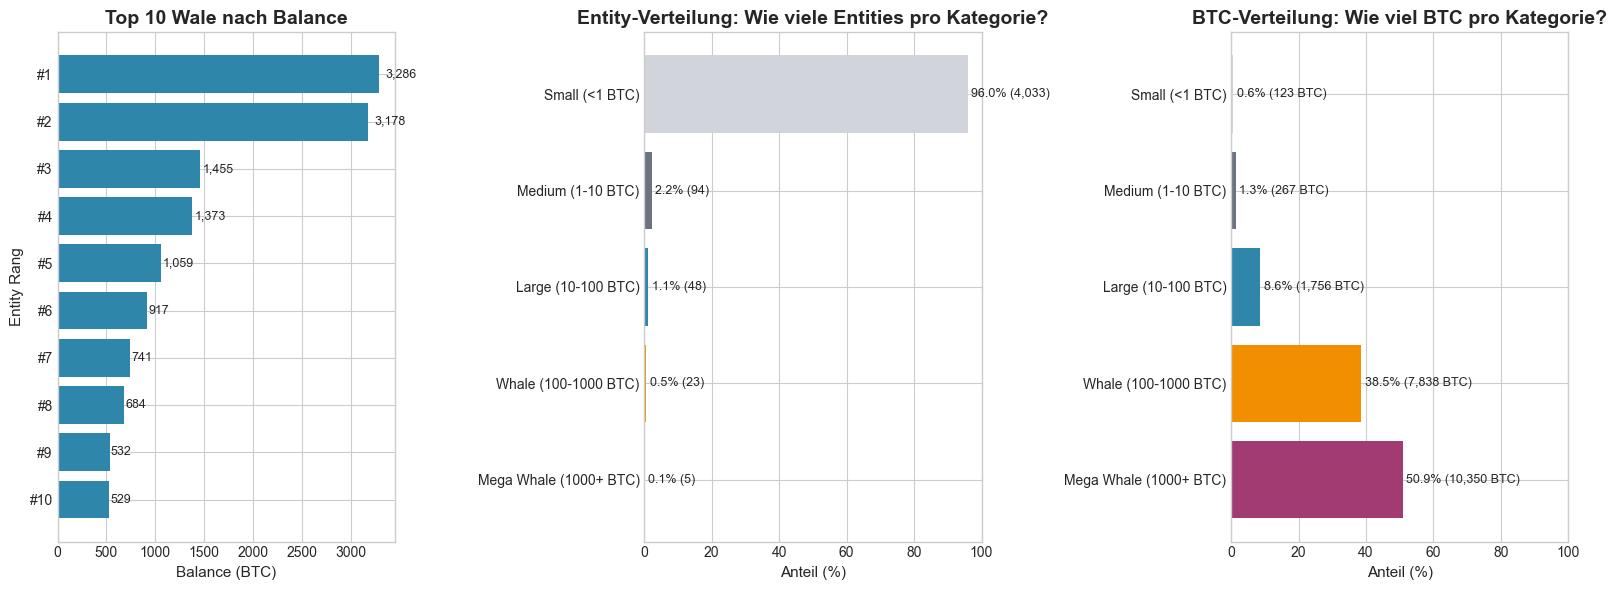


Interpretation:
- Links: Die absoluten Balancen der größten Wale
- Mitte: Wenige Mega Whales, viele kleine Entities
- Rechts: Mega Whales halten den Grossteil der BTC (extreme Konzentration)


In [28]:
# ==============================================================================
# VISUALISIERUNG: Whale-Verteilung als Balkendiagramme
# ==============================================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# Chart 1: Top 10 Wale (bleibt gleich)
top_10 = entity_balances.limit(10).toPandas()
bars = axes[0].barh(range(len(top_10)), top_10["balance_btc"], color=COLORS["primary"])
axes[0].set_xlabel("Balance (BTC)")
axes[0].set_ylabel("Entity Rang")
axes[0].set_title("Top 10 Wale nach Balance")
axes[0].set_yticks(range(len(top_10)))
axes[0].set_yticklabels([f"#{i + 1}" for i in range(len(top_10))])
axes[0].invert_yaxis()
for bar, val in zip(bars, top_10["balance_btc"], strict=False):
    axes[0].text(val + val * 0.02, bar.get_y() + bar.get_height() / 2, f"{val:,.0f}", va="center", fontsize=9)

# Chart 2: Entity-Verteilung (horizontales Balkendiagramm)
colors_bar = [COLORS["secondary"], COLORS["accent"], COLORS["primary"], "#6B7280", "#D1D5DB"]
y_pos = range(len(category_stats))
entity_pct = category_stats["entity_count"] / category_stats["entity_count"].sum() * 100

bars2 = axes[1].barh(y_pos, entity_pct, color=colors_bar[: len(category_stats)])
axes[1].set_xlabel("Anteil (%)")
axes[1].set_title("Entity-Verteilung: Wie viele Entities pro Kategorie?")
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(category_stats["category"])
axes[1].set_xlim(0, 100)
for bar, pct, cnt in zip(bars2, entity_pct, category_stats["entity_count"], strict=False):
    axes[1].text(pct + 1, bar.get_y() + bar.get_height() / 2, f"{pct:.1f}% ({cnt:,})", va="center", fontsize=9)

# Chart 3: BTC-Verteilung (horizontales Balkendiagramm)
btc_pct = category_stats["total_btc"] / category_stats["total_btc"].sum() * 100

bars3 = axes[2].barh(y_pos, btc_pct, color=colors_bar[: len(category_stats)])
axes[2].set_xlabel("Anteil (%)")
axes[2].set_title("BTC-Verteilung: Wie viel BTC pro Kategorie?")
axes[2].set_yticks(y_pos)
axes[2].set_yticklabels(category_stats["category"])
axes[2].set_xlim(0, 100)
for bar, pct, btc in zip(bars3, btc_pct, category_stats["total_btc"], strict=False):
    axes[2].text(pct + 1, bar.get_y() + bar.get_height() / 2, f"{pct:.1f}% ({btc:,.0f} BTC)", va="center", fontsize=9)

plt.tight_layout()
plt.savefig(str(Path(OUTPUT_PATH) / "whale_analysis.png"), dpi=150, bbox_inches="tight")
plt.show()

print("")
print("Interpretation:")
print("- Links: Die absoluten Balancen der größten Wale")
print("- Mitte: Wenige Mega Whales, viele kleine Entities")
print("- Rechts: Mega Whales halten den Grossteil der BTC (extreme Konzentration)")

---
## 12.1 Warum reicht ein Snapshot nicht aus?

Bisher wurde die **aktuelle** Verteilung der Bitcoin-Bestände analysiert. Aber ein statischer Snapshot beantwortet wichtige Fragen nicht:

- **Sind diese Whales Akkumulatoren oder Trader?** Halten sie langfristig oder handeln sie aktiv?
- **Wie hat sich die Konzentration entwickelt?** Werden die Großen größer?
- **Gibt es Sentiment-Signale?** Kaufen Whales vor Preisanstiegen?

Um diese Fragen zu beantworten, ist eine **Zeitreihen-Analyse** erforderlich - die Analyse betrachtet nicht nur *wer* die Whales sind, sondern *was sie mit ihren Bitcoins tun*.

Die folgenden Schritte rekonstruieren die **Balance-Historie** jeder Entity aus den Blockchain-Daten.

---
## 13. Zeitreihen-Analyse: Whale-Balance über Zeit

```
┌─────────────────────────────────────────────────────────────────────────────┐
│                    WARUM ZEITREIHEN-ANALYSE?                                │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│   Bisher: Snapshot                        Neu: Historie                     │
│                                                                             │
│   ┌─────────────────────┐                ┌─────────────────────────────┐    │
│   │ Entity 1: 1000 BTC  │                │ Entity 1:                   │    │
│   │ (Stand: heute)      │                │                             │    │
│   └─────────────────────┘                │  1000 ┤        ╭───────     │    │
│                                          │   800 ┤    ╭───╯            │    │
│   Wir wissen:                            │   600 ┤ ╭──╯                │    │
│   - Aktueller Stand                      │   400 ┤╭╯                   │    │
│   - Anzahl UTXOs                         │       └─────────────────▶   │    │
│                                          │        2015   2020   2024   │    │
│   Wir wissen NICHT:                      │                             │    │
│   - Seit wann?                           │   Akkumulation erkennbar!   │    │
│   - Kauft oder verkauft?                 └─────────────────────────────┘    │
│   - Wachstums-Trend?                                                        │
│                                                                             │
└─────────────────────────────────────────────────────────────────────────────┘
```

**Ziel:** Für jede Entity rekonstruieren, wie sich das Guthaben über Zeit entwickelt hat.

**Ansatz:**
1. Jeden Output mit Erstellungs-Zeitpunkt tracken (+BTC)
2. Jeden Input mit Ausgabe-Zeitpunkt tracken (-BTC)
3. Kumulative Summe = Balance zu jedem Zeitpunkt

### Verwendete Techniken

**Event Sourcing:** Anstatt den aktuellen Kontostand zu speichern, werden alle Änderungen als einzelne Events erfasst. Jeder UTXO erzeugt zwei Events:
- `CREATED (+BTC)`: Wenn der Output in einer Transaktion entsteht
- `SPENT (-BTC)`: Wenn der Output in einer späteren Transaktion ausgegeben wird

Der aktuelle Kontostand ergibt sich aus der Summe aller vergangenen Events.

**Window Functions:** SQL-Funktionen die über eine geordnete Menge von Zeilen arbeiten. Hier verwendet für die kumulative Summe:

```sql
SUM(delta) OVER (
    PARTITION BY entity_id    -- Pro Entity separat
    ORDER BY event_date       -- Chronologisch sortiert
)
```

**Warum diese Kombination?**
- Spark berechnet die Window Function parallel für jede Entity (Partition)
- Keine iterative Schleife nötig - eine einzige SQL-Operation
- Skaliert auf Millionen von Events

> **Fail-Safe:** Die Balance-Timeline wird als `entity_balance_timeline.parquet` materialisiert. Diese Berechnung (Window Functions über alle Events) ist rechenintensiv.
> 
> **Parallelisierung:** Window Functions (`spark_sum().over(window_spec)`) werden partitionsweise parallel ausgeführt. Jede Entity wird unabhängig berechnet.

### 13.1 UTXO History erstellen

```
┌─────────────────────────────────────────────────────────────────────────────┐
│                         OUTPUTS (mit Zeitstempel)                           │
├─────────────────────────────────────────────────────────────────────────────┤
│  tx_hash │ idx │  value  │ address │ created_at (block_timestamp)           │
│  abc123  │  0  │ 50 BTC  │   1A... │ 2015-01-01                             │
│  abc123  │  1  │ 10 BTC  │   1B... │ 2015-01-01                             │
│  def456  │  0  │ 30 BTC  │   1A... │ 2018-06-15                             │
└─────────────────────────────────────────────────────────────────────────────┘
                                    │
                                    ▼ LEFT JOIN mit Inputs
┌─────────────────────────────────────────────────────────────────────────────┐
│                         UTXO HISTORY                                        │
├─────────────────────────────────────────────────────────────────────────────┤
│  tx_hash │ idx │  value  │ address │ created_at  │ spent_at                 │
│  abc123  │  0  │ 50 BTC  │   1A... │ 2015-01-01  │ 2018-06-15  (spent!)     │
│  abc123  │  1  │ 10 BTC  │   1B... │ 2015-01-01  │ NULL        (UTXO)       │
│  def456  │  0  │ 30 BTC  │   1A... │ 2018-06-15  │ NULL        (UTXO)       │
└─────────────────────────────────────────────────────────────────────────────┘
```

**Warum?** Um Balance über Zeit zu berechnen, brauchen wir für jeden Output:
- `created_at`: Wann wurde er erstellt? (= Einzahlung auf die Adresse)
- `spent_at`: Wann wurde er ausgegeben? (= Auszahlung, NULL wenn noch UTXO)

In [29]:
%%time
# ==============================================================================
# UTXO HISTORY: Jeden Output mit Erstellungs- und Ausgabe-Zeitpunkt
# ==============================================================================

from pyspark.sql.functions import date_trunc
from pyspark.sql.window import Window

# Spent-Referenzen mit Zeitstempel (wann wurde der Output ausgegeben?)
spent_info = inputs_df.filter(~col("is_coinbase")).select(
    col("spent_tx_hash").alias("ref_tx_hash"),
    col("spent_output_index").alias("ref_output_index"),
    col("block_timestamp").alias("spent_timestamp"),
)

# Outputs mit Entity-ID anreichern (erste Adresse extrahieren)
outputs_with_addr = outputs_df.withColumn("address", element_at(col("addresses"), 1)).filter(col("address").isNotNull())

# Join mit Entities
outputs_with_entity = outputs_with_addr.join(entities_final, "address", "inner")

# UTXO History: LEFT JOIN mit spent_info
utxo_history = (
    outputs_with_entity.join(
        spent_info,
        (outputs_with_entity.tx_hash == spent_info.ref_tx_hash)
        & (outputs_with_entity.output_index == spent_info.ref_output_index),
        "left",
    )
    .select(
        outputs_with_entity.tx_hash,
        outputs_with_entity.output_index,
        outputs_with_entity.value,
        outputs_with_entity.address,
        outputs_with_entity.entity_id,
        col("block_timestamp").alias("created_timestamp"),
        col("spent_timestamp"),  # NULL wenn noch UTXO
    )
    .cache()
)

HISTORY_COUNT = utxo_history.count()
SPENT_IN_HISTORY = utxo_history.filter(col("spent_timestamp").isNotNull()).count()
UNSPENT_IN_HISTORY = HISTORY_COUNT - SPENT_IN_HISTORY

print("UTXO History erstellt")
print(f"{'=' * 50}")
print(f"Total Outputs mit Entity: {HISTORY_COUNT:,}")
print(f"Davon spent:              {SPENT_IN_HISTORY:,}")
print(f"Davon unspent (UTXOs):    {UNSPENT_IN_HISTORY:,}")

UTXO History erstellt
Total Outputs mit Entity: 197,533
Davon spent:              138,890
Davon unspent (UTXOs):    58,643
CPU times: total: 46.9 ms
Wall time: 9.02 s


### 13.2 Balance-Events erstellen

```
┌─────────────────────────────────────────────────────────────────────────────┐
│                         BALANCE EVENTS                                      │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│   Für jede Entity sammeln wir alle "Buchungen":                             │
│                                                                             │
│   ┌─────────────────────────────────────────────────────────────────────┐   │
│   │ entity_id │   datum    │   delta   │  event_type                    │   │
│   ├───────────┼────────────┼───────────┼────────────────────────────────┤   │
│   │     1     │ 2015-01-01 │  +50 BTC  │  CREATED (Output erstellt)     │   │
│   │     1     │ 2016-03-15 │  +20 BTC  │  CREATED                       │   │
│   │     1     │ 2018-06-15 │  -50 BTC  │  SPENT   (Output ausgegeben)   │   │
│   │     1     │ 2020-01-01 │ +100 BTC  │  CREATED                       │   │
│   └───────────┴────────────┴───────────┴────────────────────────────────┘   │
│                                                                             │
│   Dann: Kumulative Summe = Balance zu jedem Zeitpunkt                       │
│                                                                             │
│   2015-01-01:  +50         =   50 BTC                                       │
│   2016-03-15:  +50 +20     =   70 BTC                                       │
│   2018-06-15:  +50 +20 -50 =   20 BTC                                       │
│   2020-01-01:  ... +100    =  120 BTC                                       │
│                                                                             │
└─────────────────────────────────────────────────────────────────────────────┘
```

In [30]:
%%time
# ==============================================================================
# BALANCE EVENTS: +delta für Created, -delta für Spent
# ==============================================================================

# Event 1: Output erstellt = +value (Einzahlung)
created_events = utxo_history.select(
    col("entity_id"),
    date_trunc("day", from_unixtime(col("created_timestamp"))).alias("event_date"),
    col("value").alias("delta"),
    lit("CREATED").alias("event_type"),
)

# Event 2: Output spent = -value (Auszahlung)
spent_events = utxo_history.filter(col("spent_timestamp").isNotNull()).select(
    col("entity_id"),
    date_trunc("day", from_unixtime(col("spent_timestamp"))).alias("event_date"),
    (-col("value")).alias("delta"),
    lit("SPENT").alias("event_type"),
)

# Alle Events zusammenführen
balance_events = created_events.unionAll(spent_events).cache()

EVENT_COUNT = balance_events.count()
CREATED_COUNT = balance_events.filter(col("event_type") == "CREATED").count()
SPENT_EVENT_COUNT = balance_events.filter(col("event_type") == "SPENT").count()

print("Balance Events erstellt")
print(f"{'=' * 50}")
print(f"Total Events:    {EVENT_COUNT:,}")
print(f"CREATED (+BTC):  {CREATED_COUNT:,}")
print(f"SPENT (-BTC):    {SPENT_EVENT_COUNT:,}")

Balance Events erstellt
Total Events:    336,423
CREATED (+BTC):  197,533
SPENT (-BTC):    138,890
CPU times: total: 78.1 ms
Wall time: 8.24 s


In [31]:
%%time
# ==============================================================================
# DAILY BALANCE TIMELINE: Kumulative Summe pro Entity
# ==============================================================================

# Aggregation: Netto-Veränderung pro Entity und Tag
daily_changes = balance_events.groupBy("entity_id", "event_date").agg(spark_sum("delta").alias("daily_delta"))

# Window Function: Kumulative Summe über Zeit
window_spec = (
    Window.partitionBy("entity_id").orderBy("event_date").rowsBetween(Window.unboundedPreceding, Window.currentRow)
)

entity_balance_timeline = (
    daily_changes.withColumn("cumulative_satoshi", spark_sum("daily_delta").over(window_spec))
    .withColumn("daily_delta_btc", spark_round(col("daily_delta") / 100000000, 4))
    .withColumn("cumulative_btc", spark_round(col("cumulative_satoshi") / 100000000, 4))
    .orderBy("entity_id", "event_date")
)

# Materialisieren statt cache() für LARGE_DATASET_MODE
timeline_path = str(Path(OUTPUT_PATH) / "entity_balance_timeline.parquet")
entity_balance_timeline.write.mode("overwrite").parquet(timeline_path)
entity_balance_timeline = spark.read.parquet(timeline_path)

TIMELINE_ROWS = entity_balance_timeline.count()
TIMELINE_ENTITIES = entity_balance_timeline.select("entity_id").distinct().count()

print("Balance Timeline erstellt")
print(f"{'=' * 50}")
print(f"Timeline-Einträge: {TIMELINE_ROWS:,}")
print(f"Entities mit Historie: {TIMELINE_ENTITIES:,}")

# Timeline einer Entity anzeigen (echte Werte in BTC!)
print("\nTimeline von Top Whale (alle Werte in BTC):")
top_entity_id = entity_balances.first()["entity_id"]
entity_balance_timeline.filter(col("entity_id") == top_entity_id).select(
    "event_date", "daily_delta_btc", "cumulative_btc"
).orderBy("event_date").show(10, truncate=False)

Balance Timeline erstellt
Timeline-Einträge: 20,036
Entities mit Historie: 18,119

Timeline von Top Whale (alle Werte in BTC):
+-------------------+---------------+--------------+
|event_date         |daily_delta_btc|cumulative_btc|
+-------------------+---------------+--------------+
|2024-07-15 00:00:00|3839.5795      |3839.5795     |
|2024-07-16 00:00:00|-553.6913      |3285.8882     |
+-------------------+---------------+--------------+

CPU times: total: 93.8 ms
Wall time: 34.9 s


### 13.3 Whale-Balance-Verläufe

Visualisierung der Balance-Entwicklung der Top 5 Whales über Zeit.

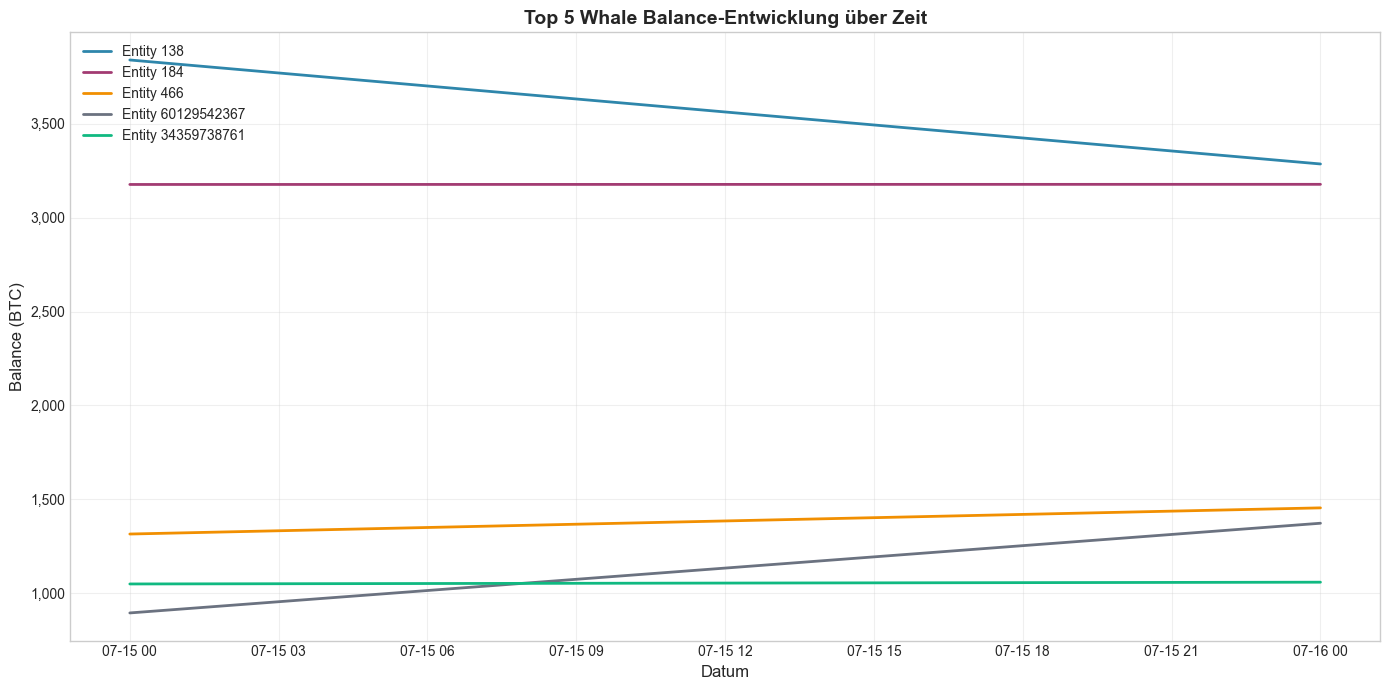

Top 5 Whale-Balance-Verläufe visualisiert.


In [32]:
# ==============================================================================
# VISUALISIERUNG: Top 5 Whale Balance über Zeit
# ==============================================================================

# Top 5 Whales nach aktuellem Balance
top_5_whales = entity_balances.limit(5).select("entity_id").toPandas()["entity_id"].tolist()

# Timeline für Top 5 extrahieren
top_whale_timeline = (
    entity_balance_timeline.filter(col("entity_id").isin(top_5_whales))
    .select("entity_id", "event_date", "cumulative_btc")
    .toPandas()
)

# Plot erstellen
fig, ax = plt.subplots(figsize=(14, 7))

colors_line = [COLORS["primary"], COLORS["secondary"], COLORS["accent"], "#6B7280", "#10B981"]

for i, entity_id in enumerate(top_5_whales):
    entity_data = top_whale_timeline[top_whale_timeline["entity_id"] == entity_id].sort_values("event_date")
    if len(entity_data) > 0:
        ax.plot(
            entity_data["event_date"],
            entity_data["cumulative_btc"],
            label=f"Entity {entity_id}",
            color=colors_line[i % len(colors_line)],
            linewidth=2,
        )

ax.set_xlabel("Datum", fontsize=12)
ax.set_ylabel("Balance (BTC)", fontsize=12)
ax.set_title("Top 5 Whale Balance-Entwicklung über Zeit", fontsize=14, fontweight="bold")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)

# Y-Achse formatieren
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"{x:,.0f}"))  # noqa: ARG005

plt.tight_layout()
plt.savefig(str(Path(OUTPUT_PATH) / "whale_timeline.png"), dpi=150, bbox_inches="tight")
plt.show()

print("Top 5 Whale-Balance-Verläufe visualisiert.")

### 13.4 Kategorien über Zeit

In diesem Abschnitt wird analysiert, wie sich die BTC-Verteilung zwischen den verschiedenen Kategorien im Laufe der Zeit verändert hat.

#### Visualisierung: Gestapeltes Flächendiagramm

Das folgende Diagramm zeigt die prozentuale Verteilung der Bitcoin-Bestände auf die verschiedenen Kategorien über die Zeit:

- **Mega Whales (1000+ BTC):** Halten typischerweise den größten Anteil
- **Whales (100-1000 BTC):** Zweite große Kategorie
- **Large (10-100 BTC):** Mittlere Holder
- **Medium/Small (<10 BTC):** Kleinere Adressen

#### Zentrale Fragestellung

Wie hat sich die Konzentration der Bitcoin-Bestände über die Zeit verändert? Werden die Reichen reicher, oder findet eine Umverteilung statt?

In [33]:
# ==============================================================================
# KATEGORIE-BALANCE ÜBER ZEIT
# ==============================================================================
from pyspark.sql.functions import concat_ws, month, year

# Entity-Kategorien mit Timeline verbinden
# Hinweis: Wir verwenden die AKTUELLE Kategorie (vereinfacht)
entity_with_category = entity_balances.select(
    col("entity_id"),
    when(col("balance_btc") >= 1000, "Mega Whale (1000+ BTC)")
    .when(col("balance_btc") >= 100, "Whale (100-1000 BTC)")
    .when(col("balance_btc") >= 10, "Large (10-100 BTC)")
    .otherwise("Small/Medium (<10 BTC)")
    .alias("category"),
)

# Timeline mit Kategorie joinen
timeline_with_category = entity_balance_timeline.join(entity_with_category, "entity_id", "inner")

# Aggregation pro Datum und Kategorie (monatlich für bessere Übersicht)
monthly_category_balance = (
    timeline_with_category.withColumn("year_month", concat_ws("-", year(col("event_date")), month(col("event_date"))))
    .groupBy("year_month", "category")
    .agg(spark_sum("cumulative_btc").alias("total_btc"))
    .orderBy("year_month", "category")
    .toPandas()
)

print(f"Monatliche Kategorie-Aggregation: {len(monthly_category_balance)} Einträge")
print(monthly_category_balance.head(10))

Monatliche Kategorie-Aggregation: 4 Einträge
  year_month                category   total_btc
0     2024-7      Large (10-100 BTC)   2634.3554
1     2024-7  Mega Whale (1000+ BTC)  20627.1694
2     2024-7  Small/Medium (<10 BTC)    695.4290
3     2024-7    Whale (100-1000 BTC)  13104.2048


In [34]:
# ==============================================================================
# AKKUMULATION VS DISTRIBUTION: Netto-Veränderung der Whales
# ==============================================================================

# Nur Whale-Kategorien (>= 100 BTC)
whale_entity_ids = (
    entity_balances.filter(col("balance_btc") >= 100).select("entity_id").toPandas()["entity_id"].tolist()
)

# Monatliche Netto-Veränderung aller Whales zusammen
whale_monthly_change = (
    balance_events.filter(col("entity_id").isin(whale_entity_ids))
    .withColumn(
        "year_month",
        concat_ws(
            "-",
            year(col("event_date")),
            when(month(col("event_date")) < 10, concat_ws("", lit("0"), month(col("event_date")))).otherwise(
                month(col("event_date"))
            ),
        ),
    )
    .groupBy("year_month")
    .agg(
        spark_sum("delta").alias("net_change_satoshi"),
        spark_sum(when(col("delta") > 0, col("delta")).otherwise(0)).alias("inflows"),
        spark_sum(when(col("delta") < 0, col("delta")).otherwise(0)).alias("outflows"),
    )
    .withColumn("net_change_btc", spark_round(col("net_change_satoshi") / 100000000, 2))
    .withColumn("inflows_btc", spark_round(col("inflows") / 100000000, 2))
    .withColumn("outflows_btc", spark_round(col("outflows") / 100000000, 2))
    .orderBy("year_month")
    .toPandas()
)

print("Whale Akkumulation/Distribution Analyse")
print(f"{'=' * 60}")
print(f"Zeiträume analysiert: {len(whale_monthly_change)}")
print("\nLetzte 12 Monate:")
print(
    whale_monthly_change.tail(12)[["year_month", "net_change_btc", "inflows_btc", "outflows_btc"]].to_string(
        index=False
    )
)

Whale Akkumulation/Distribution Analyse
Zeiträume analysiert: 1

Letzte 12 Monate:
year_month  net_change_btc  inflows_btc  outflows_btc
    2024-7        18188.56    160686.63    -142498.07


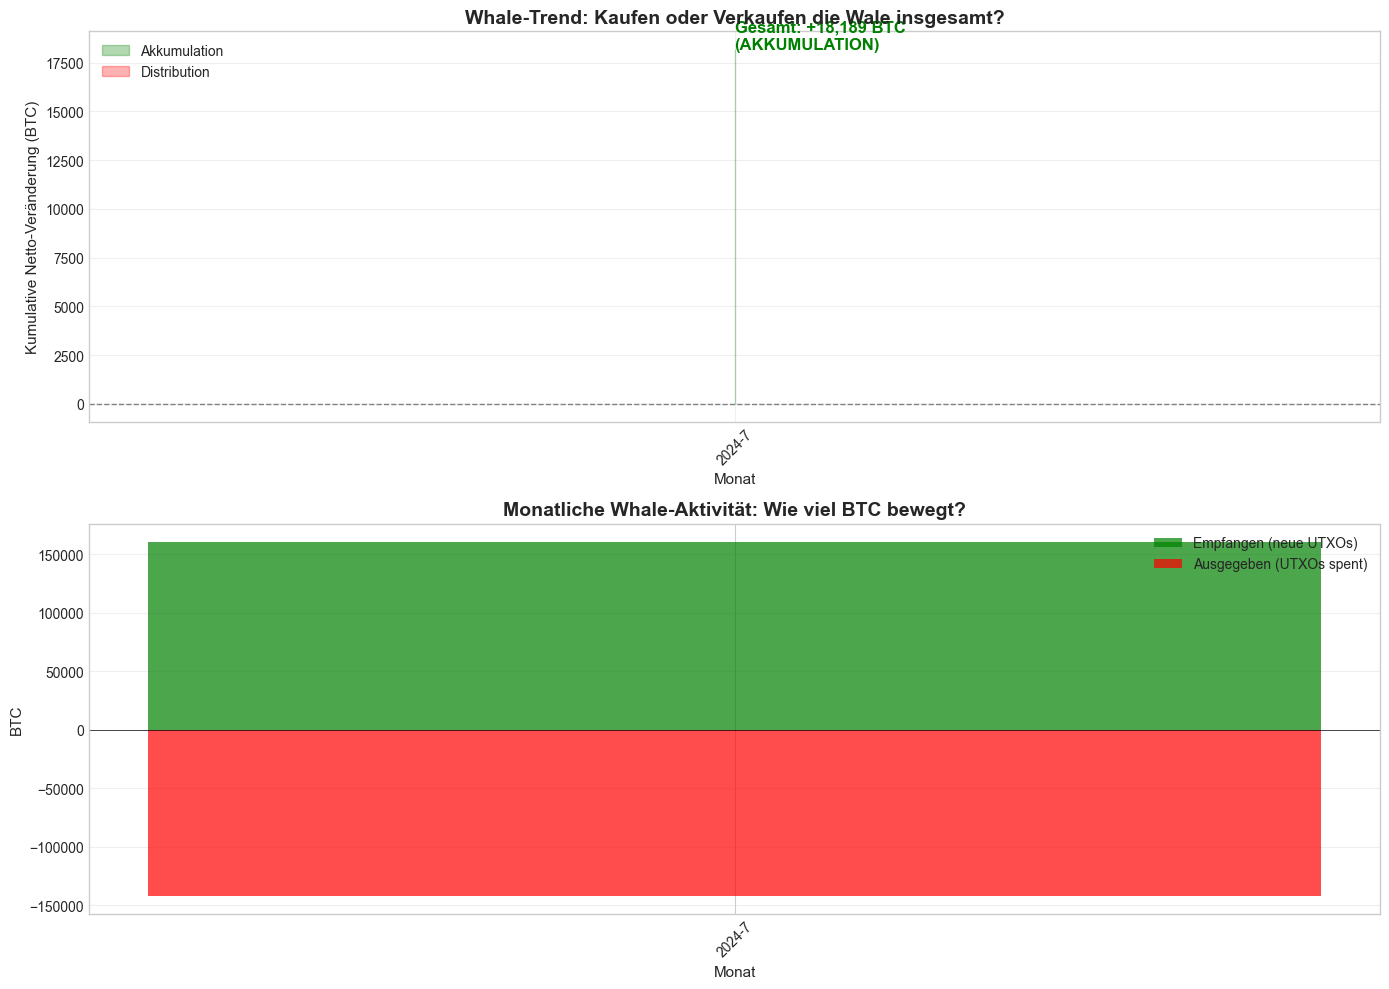


Was zeigen diese Grafiken?

Chart 1 - Kumulativer Trend:
  Zeigt ob Whales INSGESAMT mehr kaufen oder verkaufen.
  Grün = Akkumulation (Whales horten BTC)
  Rot = Distribution (Whales verkaufen BTC)

Chart 2 - Monatliche Aktivität:
  Grüne Balken = BTC die Whales ERHALTEN haben
  Rote Balken = BTC die Whales AUSGEGEBEN haben
  Je höher die Balken, desto mehr Aktivität.


In [35]:
# ==============================================================================
# VISUALISIERUNG: Whale-Aktivität über Zeit
# ==============================================================================

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Nur die letzten 24 Monate (oder alle, wenn weniger)
recent_data = whale_monthly_change.tail(24).copy()

if len(recent_data) > 0:
    # Chart 1: Kumulative Netto-Veränderung (zeigt Trend besser)
    recent_data["cumulative_net"] = recent_data["net_change_btc"].cumsum()

    ax1 = axes[0]
    ax1.fill_between(
        range(len(recent_data)),
        recent_data["cumulative_net"],
        where=recent_data["cumulative_net"] >= 0,
        alpha=0.3,
        color="green",
        label="Akkumulation",
    )
    ax1.fill_between(
        range(len(recent_data)),
        recent_data["cumulative_net"],
        where=recent_data["cumulative_net"] < 0,
        alpha=0.3,
        color="red",
        label="Distribution",
    )
    ax1.plot(range(len(recent_data)), recent_data["cumulative_net"], color="black", linewidth=2)
    ax1.axhline(y=0, color="gray", linestyle="--", linewidth=1)
    ax1.set_xlabel("Monat")
    ax1.set_ylabel("Kumulative Netto-Veränderung (BTC)")
    ax1.set_title("Whale-Trend: Kaufen oder Verkaufen die Wale insgesamt?", fontsize=14, fontweight="bold")
    ax1.set_xticks(range(0, len(recent_data), max(1, len(recent_data) // 6)))
    ax1.set_xticklabels(
        [recent_data["year_month"].iloc[i] for i in range(0, len(recent_data), max(1, len(recent_data) // 6))],
        rotation=45,
    )
    ax1.legend(loc="upper left")
    ax1.grid(True, alpha=0.3)

    # Annotation
    final_value = recent_data["cumulative_net"].iloc[-1]
    trend_text = "AKKUMULATION" if final_value > 0 else "DISTRIBUTION"
    ax1.annotate(
        f"Gesamt: {final_value:+,.0f} BTC\n({trend_text})",
        xy=(len(recent_data) - 1, final_value),
        fontsize=12,
        fontweight="bold",
        color="green" if final_value > 0 else "red",
    )

    # Chart 2: Monatliche Aktivität (Inflows vs Outflows)
    x = range(len(recent_data))
    width = 0.8

    # Stacked bar: Inflows oben, Outflows unten
    axes[1].bar(x, recent_data["inflows_btc"], width, label="Empfangen (neue UTXOs)", color="green", alpha=0.7)
    axes[1].bar(x, recent_data["outflows_btc"], width, label="Ausgegeben (UTXOs spent)", color="red", alpha=0.7)
    axes[1].axhline(y=0, color="black", linestyle="-", linewidth=0.5)
    axes[1].set_xlabel("Monat")
    axes[1].set_ylabel("BTC")
    axes[1].set_title("Monatliche Whale-Aktivität: Wie viel BTC bewegt?", fontsize=14, fontweight="bold")
    axes[1].set_xticks(range(0, len(recent_data), max(1, len(recent_data) // 6)))
    axes[1].set_xticklabels(
        [recent_data["year_month"].iloc[i] for i in range(0, len(recent_data), max(1, len(recent_data) // 6))],
        rotation=45,
    )
    axes[1].legend(loc="upper right")
    axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(str(Path(OUTPUT_PATH) / "whale_activity.png"), dpi=150, bbox_inches="tight")
plt.show()

# Erklärung
print("")
print("Was zeigen diese Grafiken?")
print("=" * 60)
print("")
print("Chart 1 - Kumulativer Trend:")
print("  Zeigt ob Whales INSGESAMT mehr kaufen oder verkaufen.")
print("  Grün = Akkumulation (Whales horten BTC)")
print("  Rot = Distribution (Whales verkaufen BTC)")
print("")
print("Chart 2 - Monatliche Aktivität:")
print("  Grüne Balken = BTC die Whales ERHALTEN haben")
print("  Rote Balken = BTC die Whales AUSGEGEBEN haben")
print("  Je höher die Balken, desto mehr Aktivität.")

### Interpretation der Zeitreihen-Analyse
Die Zeitreihen-Analyse liefert wertvolle Erkenntnisse über das Verhalten von Bitcoin-Walen. Im Folgenden werden die wichtigsten Aspekte zusammengefasst.

#### 1. Whale-Balance-Verläufe
Die Balance-Verläufe der größten Entities zeigen unterschiedliche Strategien:

- **Akkumulatoren vs. Trader:** Einige Wale akkumulieren kontinuierlich, während andere aktiv handeln
- **Sprunghafte Anstiege:** Deuten auf große Einzeltransaktionen hin
- **Flache Linien:** HODLer, die ihre Bestände ohne Aktivität halten

#### 2. Akkumulation vs. Distribution
Die aggregierten Balance-Änderungen zeigen Markttrends:

- **Grüne Balken:** Whales kaufen netto (Akkumulationsphase)
- **Rote Balken:** Whales verkaufen netto (Distributionsphase)
- Diese Daten können als Sentiment-Indikator für den Gesamtmarkt verwendet werden

#### 3. Limitationen der Analyse
Bei der Interpretation sollten folgende Einschränkungen beachtet werden:

- **Clustering-Grenzen:** Nur Adressen aus Multi-Input Transaktionen sind geclustert
- **Exchange-Wallets:** Große Börsen verwalten Millionen von Nutzer-Geldern in wenigen Wallets
- **Multi-Sig-Limitation:** Bei Adressen mit mehreren Signern wird nur die erste Adresse erfasst
- **Temporaler Bias:** Die Kategorie-Zuordnung basiert auf dem aktuellen Stand, nicht auf historischen Werten

#### 4. Warum Spark hier nötig ist
Diese Analyse erfordert erhebliche Rechenressourcen:

- Window Functions müssen über Millionen von Events berechnet werden
- Partitionierung nach Entity ermöglicht parallele Berechnung
- Bei 900+GB Blockchain-Daten ist diese Analyse nur mit einem Cluster skalierbar

In [36]:
# Daten speichern (nur was noch nicht geschrieben wurde)
from pathlib import Path


def save_if_needed(df: DataFrame, path: str, name: str) -> None:
    """Speichert DataFrame nur wenn Pfad nicht existiert oder leer ist."""
    p = Path(path)
    if not p.exists() or not any(p.iterdir()):
        print(f"Speichere {name}...")
        df.write.mode("overwrite").parquet(path)
    else:
        print(f"✓ {name} existiert bereits")


save_if_needed(entities_final, str(Path(OUTPUT_PATH) / "entities.parquet"), "entities")
# utxos, outputs, inputs wurden bereits materialisiert in früheren Zellen
print(f"\n✓ Alle Daten in {OUTPUT_PATH}")

✓ entities existiert bereits

✓ Alle Daten in ../output


---
## 14. Executive Summary

### Zielsetzung

Dieses Notebook demonstriert eine vollständige Pipeline zur Identifikation von Bitcoin-"Walen" (Entitäten mit großen BTC-Beständen) unter Verwendung von Apache Spark für Big Data Processing.

### Methodik

Die Analyse basiert auf der **Common Input Ownership Heuristic**, die besagt:

> *"Wenn mehrere Inputs in einer Transaktion verwendet werden, gehören diese mit hoher Wahrscheinlichkeit derselben Entität."*

Diese Heuristic ermöglicht es, pseudonyme Bitcoin-Adressen zu Entitäten (Personen oder Organisationen) zu gruppieren.

### Pipeline-Schritte

1. **Datenextraktion:** Bitcoin-Transaktionen aus JSON (bitcoin-etl Format)
2. **UTXO-Berechnung:** Identifikation unverbrauchter Outputs via LEFT ANTI JOIN
3. **Graph-Konstruktion:** Adressen als Knoten, Multi-Input-TXs als Kanten
4. **Clustering:** Connected Components Algorithmus (GraphFrames)
5. **Whale Detection:** Aggregation der Balances pro Entity
6. **Zeitreihen-Analyse:** Balance-Entwicklung über Zeit

### Wichtige Erkenntnisse

- **Konzentration:** Die Top-20 Whales halten einen signifikanten Anteil der analysierten BTC
- **Reduktion:** Durch Clustering werden viele Adressen zu wenigen Entitäten zusammengefasst
- **Balance-Verläufe:** Whale-Verhalten zeigt unterschiedliche Strategien (Akkumulatoren vs. Trader)

### Limitationen

- **Exchange-Wallets:** Große Börsen verzerren die Whale-Verteilung
- **Multi-Sig:** Adressen mit mehreren Signern werden nur teilweise erfasst
- **Datenumfang:** Analyse basiert auf einem Subset der Blockchain

### Technologie-Stack

- **Apache Spark 3.5+** für verteilte Datenverarbeitung
- **GraphFrames** für Graph-Algorithmen (Connected Components)
- **Parquet** für effiziente Zwischenspeicherung
- **Matplotlib/Seaborn** für Visualisierungen

In [37]:
# Zusammenfassung - Bei LARGE_DATASET_MODE Werte nachladen
if LARGE_DATASET_MODE:
    print("Lade finale Statistiken...")
    if TX_COUNT is None:
        TX_COUNT = tx_df.count()
    if OUTPUT_COUNT is None:
        OUTPUT_COUNT = outputs_df.count()
    if UTXO_COUNT is None:
        UTXO_COUNT = utxo_df.count()
    if ADDRESS_COUNT is None:
        ADDRESS_COUNT = entities_df.count()
    if ENTITY_COUNT is None:
        ENTITY_COUNT = entities_df.select("component").distinct().count()
    if ENTITIES_WITH_BALANCE is None:
        ENTITIES_WITH_BALANCE = entity_balances.count()
    if TOTAL_BTC is None:
        TOTAL_BTC = entity_balances.agg(spark_sum("balance_btc")).collect()[0][0] or 0

SPENT_COUNT = OUTPUT_COUNT - UTXO_COUNT
MEGA_WHALE_BTC = entity_balances.filter(col("balance_btc") >= 1000).agg(spark_sum("balance_btc")).collect()[0][0] or 0
MEGA_WHALE_COUNT = entity_balances.filter(col("balance_btc") >= 1000).count()
MEGA_WHALE_SHARE = MEGA_WHALE_BTC / TOTAL_BTC * 100 if TOTAL_BTC and TOTAL_BTC > 0 else 0

# Ensure REDUCTION is computed
if "REDUCTION" not in dir() or REDUCTION is None:
    REDUCTION = (1 - ENTITY_COUNT / ADDRESS_COUNT) * 100 if ADDRESS_COUNT > 0 else 0

print(f"""
{"=" * 60}
                    ANALYSE ZUSAMMENFASSUNG
{"=" * 60}

DATENUMFANG
  Transaktionen:           {TX_COUNT:>15,}
  Outputs erstellt:        {OUTPUT_COUNT:>15,}
  UTXOs (unspent):         {UTXO_COUNT:>15,}
  Spent Outputs:           {SPENT_COUNT:>15,}

ENTITY CLUSTERING
  Adressen geclustert:     {ADDRESS_COUNT:>15,}
  Entities identifiziert:  {ENTITY_COUNT:>15,}
  Reduktion:               {REDUCTION:>14.1f}%

WHALE DETECTION
  Total BTC erfasst:       {TOTAL_BTC:>15,.2f} BTC
  Entities mit Balance:    {ENTITIES_WITH_BALANCE:>15,}
  Mega-Whales (1000+ BTC): {MEGA_WHALE_COUNT:>15,} ({MEGA_WHALE_BTC:,.2f} BTC = {MEGA_WHALE_SHARE:.1f}%)

{"=" * 60}
""")

Lade finale Statistiken...

                    ANALYSE ZUSAMMENFASSUNG

DATENUMFANG
  Transaktionen:                   552,901
  Outputs erstellt:              1,385,270
  UTXOs (unspent):                 764,042
  Spent Outputs:                   621,228

ENTITY CLUSTERING
  Adressen geclustert:             156,616
  Entities identifiziert:           27,661
  Reduktion:                         82.3%

WHALE DETECTION
  Total BTC erfasst:             20,333.79 BTC
  Entities mit Balance:              4,203
  Mega-Whales (1000+ BTC):               5 (10,350.29 BTC = 50.9%)




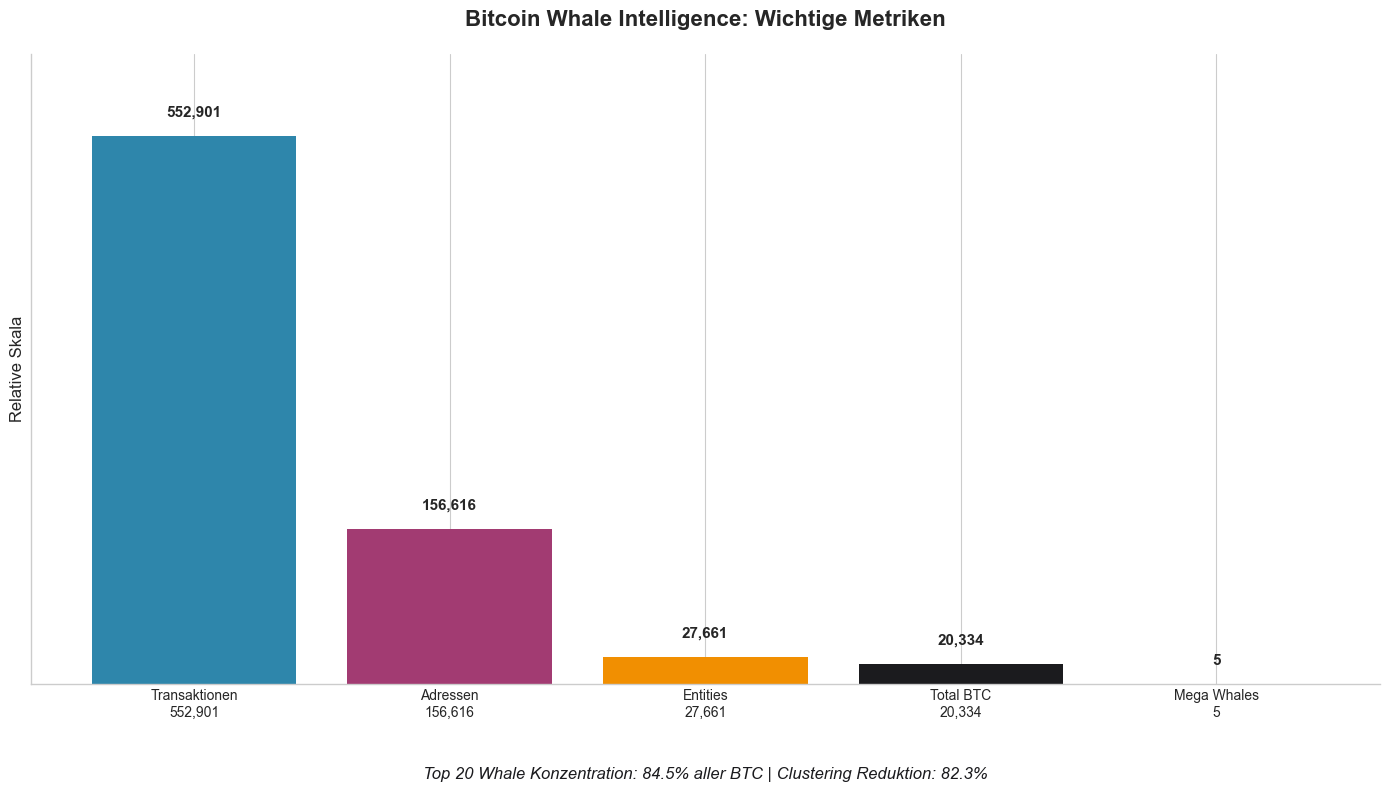

In [38]:
# Abschluss-Visualisierung: Key Metrics Overview
fig, ax = plt.subplots(figsize=(14, 8))

# Ensure all values are available (fallback to 0)
_tx = TX_COUNT or 0
_addr = ADDRESS_COUNT or 0
_ent = ENTITY_COUNT or 0
_btc = TOTAL_BTC or 0
_whale = MEGA_WHALE_COUNT if "MEGA_WHALE_COUNT" in dir() else 0

metrics = [
    f"Transaktionen\n{_tx:,}",
    f"Adressen\n{_addr:,}",
    f"Entities\n{_ent:,}",
    f"Total BTC\n{_btc:,.0f}",
    f"Mega Whales\n{_whale}",
]
values = [_tx, _addr, _ent, _btc, _whale]
max_val = max(values) if max(values) > 0 else 1
normalized = [v / max_val for v in values]

bars = ax.bar(
    metrics,
    normalized,
    color=[COLORS["primary"], COLORS["secondary"], COLORS["accent"], COLORS["dark"], COLORS["secondary"]],
)
ax.set_ylabel("Relative Skala", fontsize=12)
ax.set_title("Bitcoin Whale Intelligence: Wichtige Metriken", fontsize=16, fontweight="bold", pad=20)
ax.set_ylim(0, 1.15)

for bar, val, norm in zip(bars, values, normalized, strict=False):
    label = f"{val:,.0f}" if val >= 1000 else str(int(val))
    ax.text(
        bar.get_x() + bar.get_width() / 2, norm + 0.03, label, ha="center", va="bottom", fontsize=11, fontweight="bold"
    )

# Safe access to TOP_20_SHARE and REDUCTION
_top20 = TOP_20_SHARE if "TOP_20_SHARE" in dir() else 0
_red = REDUCTION if "REDUCTION" in dir() else 0
ax.text(
    0.5,
    -0.15,
    f"Top 20 Whale Konzentration: {_top20:.1f}% aller BTC | Clustering Reduktion: {_red:.1f}%",
    transform=ax.transAxes,
    ha="center",
    fontsize=12,
    style="italic",
    color=COLORS["dark"],
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_yticks([])

plt.tight_layout()
plt.savefig(str(Path(OUTPUT_PATH) / "executive_summary.png"), dpi=150, bbox_inches="tight")
plt.show()

In [39]:
# Spark Session (optional beenden)
# spark.stop()
print("Analyse abgeschlossen. Spark Session bleibt weiter aktiv")

Analyse abgeschlossen. Spark Session bleibt weiter aktiv


---
## 15. Zusammenfassung: Die komplette Pipeline

```
┌─────────────────────────────────────────────────────────────────────────────┐
│                    BITCOIN WHALE INTELLIGENCE PIPELINE                      │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│   ┌─────────┐                                                               │
│   │  JSON   │  Blockchain-Daten von bitcoin-etl                             │
│   └────┬────┘                                                               │
│        │                                                                    │
│        ▼                                                                    │
│   ┌─────────────────────────────────────────────────────┐                   │
│   │ Schritt 1+2: Outputs & Inputs extrahieren (explode) │                   │
│   └────────────────────────┬────────────────────────────┘                   │
│                            │                                                │
│        ┌───────────────────┼───────────────────┐                            │
│        ▼                   ▼                   ▼                            │
│   ┌─────────┐         ┌─────────┐         ┌─────────┐                       │
│   │ outputs │         │ inputs  │         │ inputs  │                       │
│   └────┬────┘         └────┬────┘         └────┬────┘                       │
│        │                   │                   │                            │
│        └─────────┬─────────┘                   │                            │
│                  ▼                             │                            │
│   ┌──────────────────────────┐                 │                            │
│   │ Schritt 3: UTXO berechnen│                 │                            │
│   │   (LEFT ANTI JOIN)       │                 │                            │
│   └────┬─────────────────────┘                 │                            │
│        │                                       │                            │
│        ▼                                       ▼                            │
│   ┌─────────┐              ┌───────────────────────────────┐                │
│   │  utxos  │              │ Schritt 4a: CoinJoin-Filter   │                │
│   └────┬────┘              │  (Whirlpool, Wasabi, Generic) │                │
│        │                   └───────────────┬───────────────┘                │
│        │                                   │                                │
│        │                                   ▼                                │
│        │                   ┌───────────────────────────────┐                │
│        │                   │ Schritt 4b: Multi-Input Kanten│                │
│        │                   │        (Adress-Paare)         │                │
│        │                   └───────────────┬───────────────┘                │
│        │                                   │                                │
│        │                                   ▼                                │
│        │                   ┌───────────────────────────────┐                │
│        │                   │ Schritt 4c: Connected         │                │
│        │                   │   Components (GraphFrames)    │                │
│        │                   └───────────────┬───────────────┘                │
│        │                                   │                                │
│        │                                   ▼                                │
│        │                              ┌─────────┐                           │
│        │                              │entities │                           │
│        │                              └────┬────┘                           │
│        │                                   │                                │
│        └─────────────────┬─────────────────┘                                │
│                          ▼                                                  │
│           ┌──────────────────────────────┐                                  │
│           │ Schritt 5: Whale Detection   │                                  │
│           │   (JOIN + GROUP BY + SUM)    │                                  │
│           └──────────────┬───────────────┘                                  │
│                          │                                                  │
│                          ▼                                                  │
│                     ┌─────────┐                                             │
│                     │  WALE   │  Entity-Balancen (Snapshot)                 │
│                     └────┬────┘                                             │
│                          │                                                  │
│   ┌──────────────────────┴───────────────────────────┐                      │
│   │                                                  │                      │
│   ▼                                                  ▼                      │
│   ┌──────────────────────────────┐    ┌──────────────────────────────┐      │
│   │ Schritt 6: Zeitreihen        │    │ Visualisierung               │      │
│   │   - UTXO History             │    │   - Top Whale Balancen       │      │
│   │   - Balance Events (+/-)     │    │   - Verteilung nach Kat.     │      │
│   │   - Window Functions         │    │   - Executive Summary        │      │
│   │   - Akkumulation/Distribution│    │                              │      │
│   └──────────────────────────────┘    └──────────────────────────────┘      │
│                  │                                                          │
│                  ▼                                                          │
│        ┌─────────────────────┐                                              │
│        │ Whale-Balance-Verläufe  │  Balance-Entwicklung über Zeit           │
│        └─────────────────────┘                                              │
│                                                                             │
└─────────────────────────────────────────────────────────────────────────────┘
```